In [113]:
# ============================================================
# STEP 1: Load dataset and inspect structure
# ============================================================

import pandas as pd
import numpy as np

# Load dataset
file_path = "/Users/anuthakur/code/DaveGiGi/Duckstradamus/Data_Processing/preprocessed_data.csv"

df = pd.read_csv(file_path)

# Convert datetime column
df["datetime_utc12"] = pd.to_datetime(df["datetime_utc12"])

# Sort by time
df = df.sort_values("datetime_utc12").reset_index(drop=True)

# Basic checks
print("Dataset shape:", df.shape)
print("\nDate range:")
print(df["datetime_utc12"].min(), "to", df["datetime_utc12"].max())

print("\nFirst 5 rows:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).head(20))

print("\nData types:")
display(df.dtypes)

Dataset shape: (52585, 81)

Date range:
2019-01-01 00:00:00 to 2024-12-31 00:00:00

First 5 rows:


,datetime_utc12,el_price_dol_MWh_BEN2201,el_price_dol_MWh_HAY2201,el_price_dol_MWh_INV2201,el_price_dol_MWh_ISL2201,el_price_dol_MWh_KIK2201,el_price_dol_MWh_OTA2201,el_price_dol_MWh_RDF2201,el_price_dol_MWh_SFD2201,el_price_dol_MWh_WKM2201,...,demand_GWh_UNI,demand_GWh_USI,avg_flow_MW,peak_flow_MW,Direction,outage_Gas_MW,outage_Hyd_MW,outage_Ter_MW,outage_Win_MW,outage_UNKN_MW
0,2019-01-01 00:00:00,169.985,171.76,180.715,181.835,184.255,176.515,166.425,169.515,167.185,...,0.910,0.528,137.5,148.0,1.0,40.0,84.0,590.0,48.3,14.0
1,2019-01-01 01:00:00,156.335,157.87,166.360,167.215,169.400,162.070,152.940,155.645,153.635,...,0.889,0.483,129.5,133.0,1.0,40.0,84.0,590.0,48.3,14.0
2,2019-01-01 02:00:00,139.650,141.00,148.550,149.095,151.050,144.645,136.500,138.990,137.120,...,0.853,0.457,126.0,128.0,1.0,40.0,84.0,590.0,48.3,14.0
3,2019-01-01 03:00:00,128.845,129.98,137.375,137.215,139.015,133.355,125.830,128.130,126.400,...,0.833,0.446,126.5,132.0,1.0,40.0,84.0,590.0,48.3,14.0
4,2019-01-01 04:00:00,134.865,136.14,144.585,143.745,145.670,139.955,132.130,134.465,132.725,...,0.835,0.460,146.0,155.0,1.0,40.0,84.0,590.0,48.3,14.0



Column names:
['datetime_utc12', 'el_price_dol_MWh_BEN2201', 'el_price_dol_MWh_HAY2201', 'el_price_dol_MWh_INV2201', 'el_price_dol_MWh_ISL2201', 'el_price_dol_MWh_KIK2201', 'el_price_dol_MWh_OTA2201', 'el_price_dol_MWh_RDF2201', 'el_price_dol_MWh_SFD2201', 'el_price_dol_MWh_WKM2201', 'Coal', 'Diesel', 'Ele', 'Gas', 'Geo', 'Hydro', 'Solar', 'Wind', 'Wood', 'palmerston_north_wind_kmh', 'palmerston_north_wind_dir_deg', 'wellington_wind_kmh', 'wellington_wind_dir_deg', 'harapaki_hawkesbay_wind_kmh', 'harapaki_hawkesbay_wind_dir_deg', 'te_uku_waikato_wind_kmh', 'te_uku_waikato_wind_dir_deg', 'kaiwera_downs_southland_wind_kmh', 'kaiwera_downs_southland_wind_dir_deg', 'auckland_shortwave_wm2', 'auckland_sunshine_s', 'christchurch_shortwave_wm2', 'christchurch_sunshine_s', 'wellington_shortwave_wm2', 'wellington_sunshine_s', 'hamilton_shortwave_wm2', 'hamilton_sunshine_s', 'tauranga_shortwave_wm2', 'tauranga_sunshine_s', 'dunedin_shortwave_wm2', 'dunedin_sunshine_s', 'auckland_temp_c', 'chris

Ele                           18
Geo                           18
Wood                          18
Wind                          18
Solar                         18
Coal                          18
Diesel                        18
Hydro                         18
Gas                           18
SI_HWE__lake_level_m           6
SI_PKI__active_storage_mm³     6
SI_PKI__lake_level_m           6
NI_WKA__active_storage_mm³     6
NI_WKA__lake_level_m           6
dunedin_sunshine_s             6
SI_TAU__lake_level_m           6
SI_MAN__active_storage_mm³     6
SI_MAN__lake_level_m           6
SI_OHA__active_storage_mm³     6
SI_OHA__lake_level_m           6
dtype: int64


Data types:


datetime_utc12              datetime64[ns]
el_price_dol_MWh_BEN2201           float64
el_price_dol_MWh_HAY2201           float64
el_price_dol_MWh_INV2201           float64
el_price_dol_MWh_ISL2201           float64
                                 ...      
outage_Gas_MW                      float64
outage_Hyd_MW                      float64
outage_Ter_MW                      float64
outage_Win_MW                      float64
outage_UNKN_MW                     float64
Length: 81, dtype: object

In [114]:
# ============================================================
# STEP 2: Select target column and identify feature groups
# ============================================================

# Target electricity price node
target_col = "el_price_dol_MWh_HAY2201"

# Datetime column
datetime_col = "datetime_utc12"

# Identify all electricity price columns
price_cols = [
    col for col in df.columns
    if col.startswith("el_price_dol_MWh")
]

# Other feature groups
generation_cols = [
    "Coal", "Diesel", "Ele", "Gas", "Geo",
    "Hydro", "Solar", "Wind", "Wood"
]

demand_cols = [
    "demand_GWh_CNI",
    "demand_GWh_LNI",
    "demand_GWh_LSI",
    "demand_GWh_UNI",
    "demand_GWh_USI"
]

flow_cols = [
    "avg_flow_MW",
    "peak_flow_MW",
    "Direction"
]

outage_cols = [
    "outage_Gas_MW",
    "outage_Hyd_MW",
    "outage_Ter_MW",
    "outage_Win_MW",
    "outage_UNKN_MW"
]

weather_cols = [
    col for col in df.columns
    if (
        "temp" in col
        or "wind" in col
        or "shortwave" in col
        or "sunshine" in col
    )
]

lake_cols = [
    col for col in df.columns
    if "lake_level" in col or "active_storage" in col
]

calendar_cols = ["holiday"]

print("Target column:")
print(target_col)

print("\nNumber of price columns:", len(price_cols))
print(price_cols)

print("\nNumber of generation columns:", len(generation_cols))
print(generation_cols)

print("\nNumber of demand columns:", len(demand_cols))
print(demand_cols)

print("\nNumber of weather columns:", len(weather_cols))
print(weather_cols)

print("\nNumber of lake columns:", len(lake_cols))
print(lake_cols)

print("\nNumber of outage columns:", len(outage_cols))
print(outage_cols)

Target column:
el_price_dol_MWh_HAY2201

Number of price columns: 9
['el_price_dol_MWh_BEN2201', 'el_price_dol_MWh_HAY2201', 'el_price_dol_MWh_INV2201', 'el_price_dol_MWh_ISL2201', 'el_price_dol_MWh_KIK2201', 'el_price_dol_MWh_OTA2201', 'el_price_dol_MWh_RDF2201', 'el_price_dol_MWh_SFD2201', 'el_price_dol_MWh_WKM2201']

Number of generation columns: 9
['Coal', 'Diesel', 'Ele', 'Gas', 'Geo', 'Hydro', 'Solar', 'Wind', 'Wood']

Number of demand columns: 5
['demand_GWh_CNI', 'demand_GWh_LNI', 'demand_GWh_LSI', 'demand_GWh_UNI', 'demand_GWh_USI']

Number of weather columns: 28
['palmerston_north_wind_kmh', 'palmerston_north_wind_dir_deg', 'wellington_wind_kmh', 'wellington_wind_dir_deg', 'harapaki_hawkesbay_wind_kmh', 'harapaki_hawkesbay_wind_dir_deg', 'te_uku_waikato_wind_kmh', 'te_uku_waikato_wind_dir_deg', 'kaiwera_downs_southland_wind_kmh', 'kaiwera_downs_southland_wind_dir_deg', 'auckland_shortwave_wm2', 'auckland_sunshine_s', 'christchurch_shortwave_wm2', 'christchurch_sunshine_s', 'w

Target Summary Statistics


count    52585.000000
mean       135.353125
std        116.386199
min          0.010000
25%         69.790000
50%        116.300000
75%        180.775000
max       4035.905000
Name: el_price_dol_MWh_HAY2201, dtype: float64


Missing Values: 0


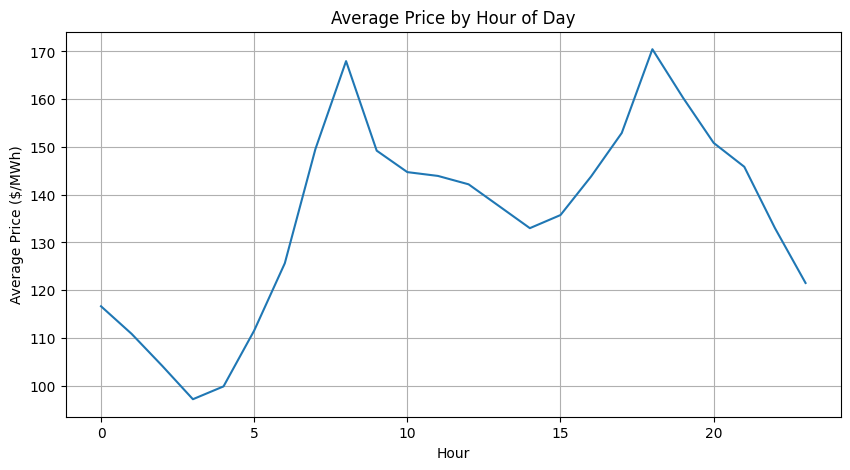

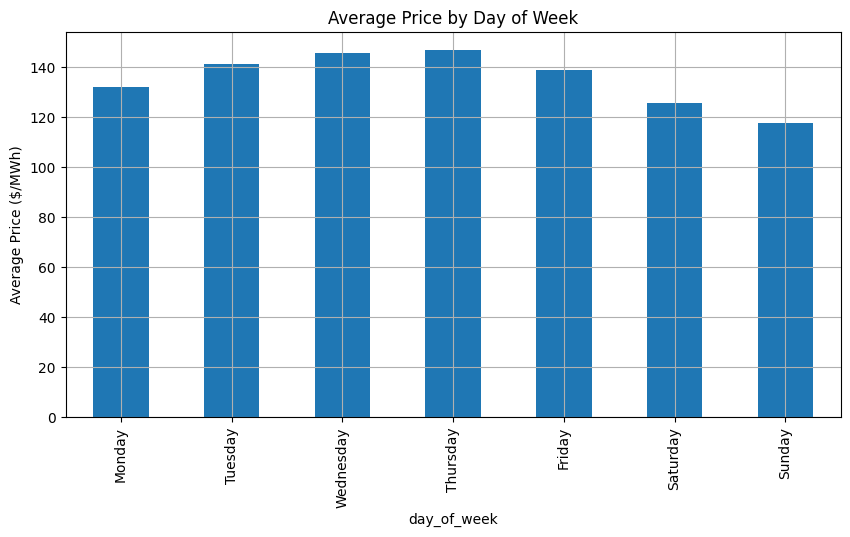

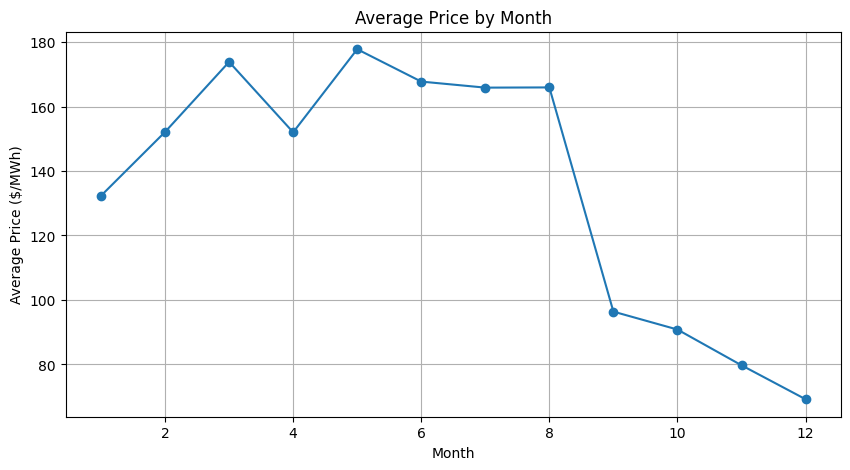

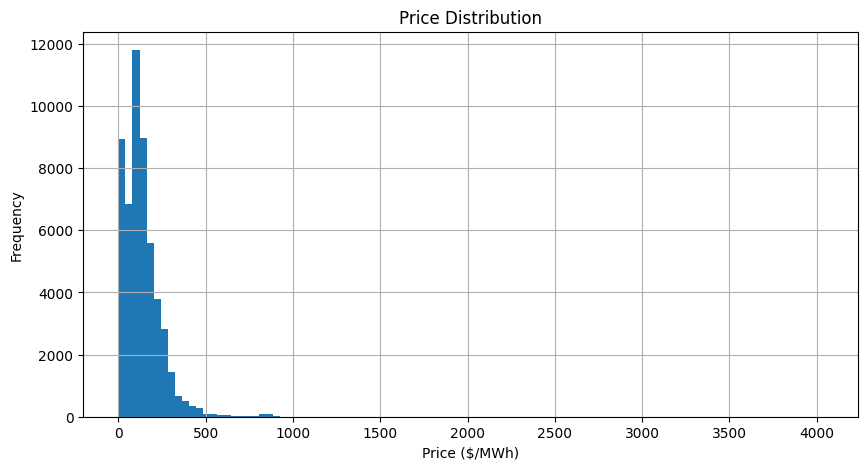

In [115]:
# ============================================================
# STEP 3: Explore target behaviour
# ============================================================

import matplotlib.pyplot as plt

# Basic statistics
print("Target Summary Statistics")
display(df[target_col].describe())

print("\nMissing Values:", df[target_col].isna().sum())

# ----------------------------------------------------
# Daily Pattern
# ----------------------------------------------------

df["hour"] = df[datetime_col].dt.hour

hourly_avg = (
    df.groupby("hour")[target_col]
      .mean()
)

plt.figure(figsize=(10,5))
hourly_avg.plot()
plt.title("Average Price by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Average Price ($/MWh)")
plt.grid(True)
plt.show()

# ----------------------------------------------------
# Weekly Pattern
# ----------------------------------------------------

df["day_of_week"] = df[datetime_col].dt.day_name()

weekly_avg = (
    df.groupby("day_of_week")[target_col]
      .mean()
)

week_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekly_avg = weekly_avg.reindex(week_order)

plt.figure(figsize=(10,5))
weekly_avg.plot(kind="bar")
plt.title("Average Price by Day of Week")
plt.ylabel("Average Price ($/MWh)")
plt.grid(True)
plt.show()

# ----------------------------------------------------
# Monthly Pattern
# ----------------------------------------------------

df["month"] = df[datetime_col].dt.month

monthly_avg = (
    df.groupby("month")[target_col]
      .mean()
)

plt.figure(figsize=(10,5))
monthly_avg.plot(marker="o")
plt.title("Average Price by Month")
plt.xlabel("Month")
plt.ylabel("Average Price ($/MWh)")
plt.grid(True)
plt.show()

# ----------------------------------------------------
# Price Distribution
# ----------------------------------------------------

plt.figure(figsize=(10,5))
df[target_col].hist(bins=100)
plt.title("Price Distribution")
plt.xlabel("Price ($/MWh)")
plt.ylabel("Frequency")
plt.show()

,el_price_dol_MWh_BEN2201,el_price_dol_MWh_HAY2201,el_price_dol_MWh_INV2201,el_price_dol_MWh_ISL2201,el_price_dol_MWh_KIK2201,el_price_dol_MWh_OTA2201,el_price_dol_MWh_RDF2201,el_price_dol_MWh_SFD2201,el_price_dol_MWh_WKM2201
el_price_dol_MWh_BEN2201,1.000,0.965,0.992,1.000,0.999,0.950,0.939,0.959,0.957
el_price_dol_MWh_HAY2201,0.965,1.000,0.956,0.966,0.966,0.992,0.977,0.998,0.996
el_price_dol_MWh_INV2201,0.992,0.956,1.000,0.992,0.991,0.937,0.927,0.948,0.944
el_price_dol_MWh_ISL2201,1.000,0.966,0.992,1.000,1.000,0.950,0.939,0.959,0.957
el_price_dol_MWh_KIK2201,0.999,0.966,0.991,1.000,1.000,0.951,0.940,0.960,0.958
el_price_dol_MWh_OTA2201,0.950,0.992,0.937,0.950,0.951,1.000,0.976,0.996,0.994
el_price_dol_MWh_RDF2201,0.939,0.977,0.927,0.939,0.940,0.976,1.000,0.979,0.982
el_price_dol_MWh_SFD2201,0.959,0.998,0.948,0.959,0.960,0.996,0.979,1.000,0.997
el_price_dol_MWh_WKM2201,0.957,0.996,0.944,0.957,0.958,0.994,0.982,0.997,1.000


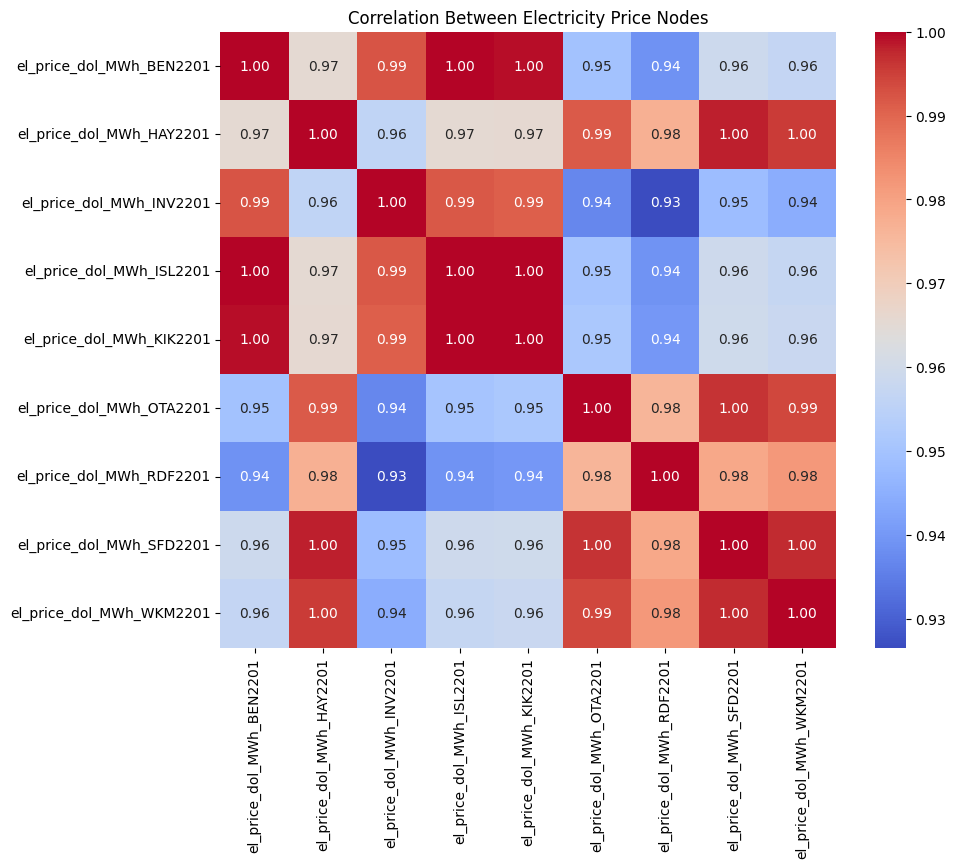

In [116]:
# ============================================================
# STEP 4: Correlation among electricity price nodes
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt

price_corr = df[price_cols].corr()

display(price_corr.round(3))

plt.figure(figsize=(10, 8))

sns.heatmap(
    price_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)

plt.title("Correlation Between Electricity Price Nodes")
plt.show()

In [117]:
# ============================================================
# STEP 4: Create calendar features
# ============================================================

df["hour"] = df[datetime_col].dt.hour

df["day_of_week"] = df[datetime_col].dt.dayofweek

df["month"] = df[datetime_col].dt.month

df["day_of_year"] = df[datetime_col].dt.dayofyear

df["week_of_year"] = (
    df[datetime_col]
    .dt.isocalendar()
    .week
    .astype(int)
)

df["quarter"] = df[datetime_col].dt.quarter

df["is_weekend"] = (
    df["day_of_week"]
    .isin([5, 6])
    .astype(int)
)

calendar_features = [
    "hour",
    "day_of_week",
    "month",
    "day_of_year",
    "week_of_year",
    "quarter",
    "is_weekend"
]

print("Calendar features created")

display(df[calendar_features].head())

Calendar features created


,hour,day_of_week,month,day_of_year,week_of_year,quarter,is_weekend
0,0,1,1,1,1,1,0
1,1,1,1,1,1,1,0
2,2,1,1,1,1,1,0
3,3,1,1,1,1,1,0
4,4,1,1,1,1,1,0


In [118]:
# ============================================================
# STEP 5: Create cyclical time features
# ============================================================

import numpy as np

# ----------------------------
# Hour
# ----------------------------

df["hour_sin"] = np.sin(
    2 * np.pi * df["hour"] / 24
)

df["hour_cos"] = np.cos(
    2 * np.pi * df["hour"] / 24
)

# ----------------------------
# Day of Week
# ----------------------------

df["dow_sin"] = np.sin(
    2 * np.pi * df["day_of_week"] / 7
)

df["dow_cos"] = np.cos(
    2 * np.pi * df["day_of_week"] / 7
)

# ----------------------------
# Month
# ----------------------------

df["month_sin"] = np.sin(
    2 * np.pi * df["month"] / 12
)

df["month_cos"] = np.cos(
    2 * np.pi * df["month"] / 12
)

# ----------------------------
# Day of Year
# ----------------------------

df["doy_sin"] = np.sin(
    2 * np.pi * df["day_of_year"] / 365.25
)

df["doy_cos"] = np.cos(
    2 * np.pi * df["day_of_year"] / 365.25
)

cyclical_features = [
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos",
    "doy_sin",
    "doy_cos"
]

print("Cyclical features created")

display(df[cyclical_features].head())

Cyclical features created


,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,doy_sin,doy_cos
0,0.000000,1.000000,0.781831,0.62349,0.5,0.866025,0.017202,0.999852
1,0.258819,0.965926,0.781831,0.62349,0.5,0.866025,0.017202,0.999852
2,0.500000,0.866025,0.781831,0.62349,0.5,0.866025,0.017202,0.999852
3,0.707107,0.707107,0.781831,0.62349,0.5,0.866025,0.017202,0.999852
4,0.866025,0.500000,0.781831,0.62349,0.5,0.866025,0.017202,0.999852


In [119]:
# ============================================================
# STEP 6: Create target variable
# Predict HAY price 24 hours ahead
# ============================================================

forecast_horizon = 24

df["target"] = (
    df[target_col]
    .shift(-forecast_horizon)
)

print("Target Created")

print("\nCurrent Price:")
print(target_col)

print("\nForecast Horizon:")
print(f"{forecast_horizon} hours")

display(
    df[
        [
            datetime_col,
            target_col,
            "target"
        ]
    ].head(30)
)

Target Created

Current Price:
el_price_dol_MWh_HAY2201

Forecast Horizon:
24 hours


,datetime_utc12,el_price_dol_MWh_HAY2201,target
0,2019-01-01 00:00:00,171.760,73.805
1,2019-01-01 01:00:00,157.870,83.615
2,2019-01-01 02:00:00,141.000,79.310
3,2019-01-01 03:00:00,129.980,95.630
4,2019-01-01 04:00:00,136.140,95.165
5,2019-01-01 05:00:00,137.360,74.185
6,2019-01-01 06:00:00,98.935,63.795
7,2019-01-01 07:00:00,81.665,69.015
8,2019-01-01 08:00:00,85.435,87.450
9,2019-01-01 09:00:00,145.450,108.515


In [120]:
# ============================================================
# STEP 7: Create price lag features
# ============================================================

price_lags = [
    1,
    2,
    3,
    6,
    12,
    24,
    48,
    72,
    168,
    336,
    720
]

for lag in price_lags:

    df[f"price_lag_{lag}"] = (
        df[target_col]
        .shift(lag)
    )

created_lags = [
    col for col in df.columns
    if col.startswith("price_lag_")
]

print("Number of lag features created:", len(created_lags))

display(
    df[
        [
            target_col,
            "price_lag_1",
            "price_lag_24",
            "price_lag_168"
        ]
    ].head(30)
)

Number of lag features created: 11


,el_price_dol_MWh_HAY2201,price_lag_1,price_lag_24,price_lag_168
0,171.760,NaN,NaN,NaN
1,157.870,171.760,NaN,NaN
2,141.000,157.870,NaN,NaN
3,129.980,141.000,NaN,NaN
4,136.140,129.980,NaN,NaN
5,137.360,136.140,NaN,NaN
6,98.935,137.360,NaN,NaN
7,81.665,98.935,NaN,NaN
8,85.435,81.665,NaN,NaN
9,145.450,85.435,NaN,NaN


In [121]:
# ============================================================
# STEP 8: Create rolling features (LEAKAGE SAFE)
# ============================================================

# Daily behaviour
df["price_roll_mean_24"] = (
    df[target_col]
    .shift(1)
    .rolling(24)
    .mean()
)

df["price_roll_std_24"] = (
    df[target_col]
    .shift(1)
    .rolling(24)
    .std()
)

# Weekly behaviour
df["price_roll_mean_168"] = (
    df[target_col]
    .shift(1)
    .rolling(168)
    .mean()
)

df["price_roll_std_168"] = (
    df[target_col]
    .shift(1)
    .rolling(168)
    .std()
)

# Monthly behaviour
df["price_roll_mean_720"] = (
    df[target_col]
    .shift(1)
    .rolling(720)
    .mean()
)

rolling_features = [
    "price_roll_mean_24",
    "price_roll_std_24",
    "price_roll_mean_168",
    "price_roll_std_168",
    "price_roll_mean_720"
]

print("Rolling features created")

display(
    df[
        [
            target_col,
            "price_roll_mean_24",
            "price_roll_std_24",
            "price_roll_mean_168",
            "price_roll_std_168"
        ]
    ].head(200)
)

Rolling features created


,el_price_dol_MWh_HAY2201,price_roll_mean_24,price_roll_std_24,price_roll_mean_168,price_roll_std_168
0,171.760,NaN,NaN,NaN,NaN
1,157.870,NaN,NaN,NaN,NaN
2,141.000,NaN,NaN,NaN,NaN
3,129.980,NaN,NaN,NaN,NaN
4,136.140,NaN,NaN,NaN,NaN
...,...,...,...,...,...
195,104.810,154.566042,29.924821,127.649345,32.435454
196,92.330,153.570208,31.193443,127.703988,32.388888
197,126.010,151.967917,33.329248,127.687113,32.406676
198,146.195,151.654167,33.545009,127.995595,32.139900


In [122]:
# ============================================================
# STEP 9: Correlation with target
# ============================================================

corr_target = (
    df.drop(columns=[datetime_col])
      .corr(numeric_only=True)[target_col]
      .sort_values(ascending=False)
)

print("Top 30 correlations with target price")

display(corr_target.head(30))

Top 30 correlations with target price


el_price_dol_MWh_HAY2201    1.000000
el_price_dol_MWh_SFD2201    0.998023
el_price_dol_MWh_WKM2201    0.995616
el_price_dol_MWh_OTA2201    0.991606
el_price_dol_MWh_RDF2201    0.977058
el_price_dol_MWh_KIK2201    0.965808
el_price_dol_MWh_ISL2201    0.965572
el_price_dol_MWh_BEN2201    0.965314
el_price_dol_MWh_INV2201    0.955926
price_lag_1                 0.846091
price_roll_mean_24          0.802227
price_lag_2                 0.755366
price_roll_mean_168         0.735268
price_lag_24                0.725954
target                      0.725954
price_lag_3                 0.717054
price_lag_6                 0.655399
price_lag_12                0.649136
price_lag_48                0.647445
price_roll_mean_720         0.623700
price_lag_72                0.606835
Coal                        0.579428
price_lag_168               0.564232
price_lag_336               0.473495
Gas                         0.444123
Diesel                      0.394811
price_lag_720               0.359330
d

In [123]:
# ============================================================
# STEP 10: Top non-price predictors - corrected
# ============================================================

# Columns we do NOT want as predictors
exclude_cols = price_cols + ["target", datetime_col]

# Keep only non-price columns + target_col for correlation calculation
corr_df = df.drop(
    columns=[
        col for col in exclude_cols
        if col != target_col and col in df.columns
    ]
)

corr_non_price = (
    corr_df
    .corr(numeric_only=True)[target_col]
    .drop(target_col)
    .sort_values(
        ascending=False,
        key=lambda x: abs(x)
    )
)

print("Top 30 NON-PRICE predictors")

display(corr_non_price.head(30))

Top 30 NON-PRICE predictors


price_lag_1                   0.846091
price_roll_mean_24            0.802227
price_lag_2                   0.755366
price_roll_mean_168           0.735268
price_lag_24                  0.725954
price_lag_3                   0.717054
price_lag_6                   0.655399
price_lag_12                  0.649136
price_lag_48                  0.647445
price_roll_mean_720           0.623700
price_lag_72                  0.606835
Coal                          0.579428
price_lag_168                 0.564232
price_lag_336                 0.473495
Gas                           0.444123
SI_WAN__active_storage_mm³   -0.399805
SI_WAN__lake_level_m         -0.399795
Diesel                        0.394811
NI_TPO__active_storage_mm³   -0.393653
NI_TPO__lake_level_m         -0.393642
SI_WPU__lake_level_m         -0.384779
SI_WPU__active_storage_mm³   -0.384764
price_lag_720                 0.359330
SI_PKI__lake_level_m         -0.352518
SI_PKI__active_storage_mm³   -0.351984
demand_GWh_USI           

In [124]:
# ============================================================
# STEP 11: Create lags for strongest physical drivers
# ============================================================

physical_features = [
    "Coal",
    "Gas",
    "Diesel",
    "demand_GWh_CNI",
    "demand_GWh_UNI",
    "SI_WAN__active_storage_mm³",
    "NI_TPO__active_storage_mm³"
]

lags = [24, 168]

for feature in physical_features:

    for lag in lags:

        df[f"{feature}_lag_{lag}"] = (
            df[feature]
            .shift(lag)
        )

print("Physical feature lags created")

new_cols = [
    col for col in df.columns
    if "_lag_" in col
]

print("Total lag columns:", len(new_cols))

Physical feature lags created
Total lag columns: 25


In [125]:
# ============================================================
# STEP 12: Build final feature list
# ============================================================

# Columns that MUST NOT be used
exclude_cols = (
    [datetime_col]
    + price_cols          # all current prices
    + ["target"]          # prediction target
)

feature_cols = [
    col for col in df.columns
    if col not in exclude_cols
]

print("Number of Features:", len(feature_cols))

print("\nFirst 50 Features:")
print(feature_cols[:50])

# Quick sanity check
print("\nLeakage Check")

for col in exclude_cols:
    if col in feature_cols:
        print("❌ Leakage Found:", col)

print("✅ Leakage Audit Complete")

Number of Features: 116

First 50 Features:
['Coal', 'Diesel', 'Ele', 'Gas', 'Geo', 'Hydro', 'Solar', 'Wind', 'Wood', 'palmerston_north_wind_kmh', 'palmerston_north_wind_dir_deg', 'wellington_wind_kmh', 'wellington_wind_dir_deg', 'harapaki_hawkesbay_wind_kmh', 'harapaki_hawkesbay_wind_dir_deg', 'te_uku_waikato_wind_kmh', 'te_uku_waikato_wind_dir_deg', 'kaiwera_downs_southland_wind_kmh', 'kaiwera_downs_southland_wind_dir_deg', 'auckland_shortwave_wm2', 'auckland_sunshine_s', 'christchurch_shortwave_wm2', 'christchurch_sunshine_s', 'wellington_shortwave_wm2', 'wellington_sunshine_s', 'hamilton_shortwave_wm2', 'hamilton_sunshine_s', 'tauranga_shortwave_wm2', 'tauranga_sunshine_s', 'dunedin_shortwave_wm2', 'dunedin_sunshine_s', 'auckland_temp_c', 'christchurch_temp_c', 'wellington_temp_c', 'hamilton_temp_c', 'tauranga_temp_c', 'dunedin_temp_c', 'SI_TKA__lake_level_m', 'SI_TKA__active_storage_mm³', 'SI_OHA__lake_level_m', 'SI_OHA__active_storage_mm³', 'SI_MAN__lake_level_m', 'SI_MAN__active

In [126]:
# ============================================================
# STEP 13: Check missing values after feature engineering
# ============================================================

missing_counts = (
    df[feature_cols + ["target"]]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print("Top columns with missing values:")

display(
    missing_counts[
        missing_counts > 0
    ].head(20)
)

print("\nRows before cleaning:")
print(len(df))

Top columns with missing values:


price_lag_720                         720
price_roll_mean_720                   720
price_lag_336                         336
Coal_lag_168                          186
Gas_lag_168                           186
Diesel_lag_168                        186
SI_WAN__active_storage_mm³_lag_168    174
NI_TPO__active_storage_mm³_lag_168    174
demand_GWh_UNI_lag_168                168
demand_GWh_CNI_lag_168                168
price_lag_168                         168
price_roll_std_168                    168
price_roll_mean_168                   168
price_lag_72                           72
price_lag_48                           48
Diesel_lag_24                          42
Coal_lag_24                            42
Gas_lag_24                             42
SI_WAN__active_storage_mm³_lag_24      30
NI_TPO__active_storage_mm³_lag_24      30
dtype: int64


Rows before cleaning:
52585


In [127]:
# ============================================================
# STEP 14: Create final modeling dataset
# ============================================================

model_df = df[feature_cols + ["target"]].copy()

print("Rows before cleaning:")
print(len(model_df))

model_df = model_df.dropna()

print("\nRows after cleaning:")
print(len(model_df))

print("\nRows removed:")
print(len(df) - len(model_df))

print("\nPercentage removed:")
print(
    round(
        (len(df) - len(model_df))
        / len(df)
        * 100,
        2
    ),
    "%"
)

display(model_df.head())

Rows before cleaning:
52585

Rows after cleaning:
51787

Rows removed:
798

Percentage removed:
1.52 %


,Coal,Diesel,Ele,Gas,Geo,Hydro,Solar,Wind,Wood,palmerston_north_wind_kmh,...,Diesel_lag_168,demand_GWh_CNI_lag_24,demand_GWh_CNI_lag_168,demand_GWh_UNI_lag_24,demand_GWh_UNI_lag_168,SI_WAN__active_storage_mm³_lag_24,SI_WAN__active_storage_mm³_lag_168,NI_TPO__active_storage_mm³_lag_24,NI_TPO__active_storage_mm³_lag_168,target
720,226311.0,0.0,0.0,442513.1855,839207.26,2.316311e+06,0.0,93222.3850,0.0,7.1,...,0.0,0.842,0.797,1.019,0.985,394.733000,377.806000,502.977000,538.729000,127.455
721,227029.0,0.0,0.0,411466.4857,841337.82,2.202964e+06,0.0,98888.3569,0.0,7.9,...,0.0,0.821,0.782,0.979,0.948,394.483667,378.236917,502.741125,538.307708,124.565
722,227242.0,0.0,0.0,410558.8634,829088.24,2.139620e+06,0.0,91668.2715,0.0,8.4,...,0.0,0.805,0.763,0.969,0.927,394.234333,378.667833,502.505250,537.886417,123.045
723,227636.0,0.0,0.0,411862.0575,821532.12,2.154292e+06,0.0,80679.2749,0.0,8.1,...,0.0,0.794,0.757,0.960,0.920,393.985000,379.098750,502.269375,537.465125,122.860
724,225928.0,0.0,0.0,412033.5246,825456.38,2.301335e+06,0.0,89608.9767,0.0,6.6,...,0.0,0.811,0.795,1.001,0.958,393.735667,379.529667,502.033500,537.043833,133.460


In [128]:
# ============================================================
# STEP 15: Time-based split
# ============================================================

# Bring datetime back for splitting
split_df = df.loc[model_df.index].copy()

train_df = split_df[
    split_df[datetime_col] < "2023-01-01"
]

val_df = split_df[
    (split_df[datetime_col] >= "2023-01-01")
    &
    (split_df[datetime_col] < "2024-01-01")
]

test_df = split_df[
    split_df[datetime_col] >= "2024-01-01"
]

print("Train Shape:", train_df.shape)
print("Validation Shape:", val_df.shape)
print("Test Shape:", test_df.shape)

print("\nTrain Period:")
print(
    train_df[datetime_col].min(),
    "to",
    train_df[datetime_col].max()
)

print("\nValidation Period:")
print(
    val_df[datetime_col].min(),
    "to",
    val_df[datetime_col].max()
)

print("\nTest Period:")
print(
    test_df[datetime_col].min(),
    "to",
    test_df[datetime_col].max()
)

Train Shape: (34308, 127)
Validation Shape: (8751, 127)
Test Shape: (8728, 127)

Train Period:
2019-01-31 00:00:00 to 2022-12-31 23:00:00

Validation Period:
2023-01-01 00:00:00 to 2023-12-31 23:00:00

Test Period:
2024-01-01 00:00:00 to 2024-12-30 00:00:00


In [129]:
# ============================================================
# STEP 16: Persistence baseline
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Validation set
y_val = val_df["target"]

y_pred_persist = val_df[target_col]

mae = mean_absolute_error(
    y_val,
    y_pred_persist
)

rmse = mean_squared_error(
    y_val,
    y_pred_persist
) ** 0.5

r2 = r2_score(
    y_val,
    y_pred_persist
)

print("Persistence Baseline")

print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")

Persistence Baseline
MAE  : 39.393
RMSE : 90.181
R²   : 0.047


In [130]:
# ============================================================
# STEP 17: Weekly seasonal baseline
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

y_val = val_df["target"]

y_pred_week = val_df["price_lag_168"]

mae = mean_absolute_error(
    y_val,
    y_pred_week
)

rmse = mean_squared_error(
    y_val,
    y_pred_week
) ** 0.5

r2 = r2_score(
    y_val,
    y_pred_week
)

print("Weekly Baseline")

print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")

Weekly Baseline
MAE  : 55.940
RMSE : 116.201
R²   : -0.582


In [131]:
# ============================================================
# STEP 18: Create Version 1 feature set
# ============================================================

v1_features = [

    # Calendar
    "hour",
    "day_of_week",
    "month",
    "day_of_year",
    "week_of_year",
    "quarter",
    "is_weekend",

    # Cyclical
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos",
    "doy_sin",
    "doy_cos",

    # Price lags
    "price_lag_1",
    "price_lag_2",
    "price_lag_3",
    "price_lag_6",
    "price_lag_12",
    "price_lag_24",
    "price_lag_48",
    "price_lag_72",
    "price_lag_168",
    "price_lag_336",
    "price_lag_720",

    # Rolling
    "price_roll_mean_24",
    "price_roll_std_24",
    "price_roll_mean_168",
    "price_roll_std_168",
    "price_roll_mean_720",

    # Physical driver lags
    "Coal_lag_24",
    "Coal_lag_168",

    "Gas_lag_24",
    "Gas_lag_168",

    "Diesel_lag_24",
    "Diesel_lag_168",

    "demand_GWh_CNI_lag_24",
    "demand_GWh_CNI_lag_168",

    "demand_GWh_UNI_lag_24",
    "demand_GWh_UNI_lag_168",

    "SI_WAN__active_storage_mm³_lag_24",
    "SI_WAN__active_storage_mm³_lag_168",

    "NI_TPO__active_storage_mm³_lag_24",
    "NI_TPO__active_storage_mm³_lag_168"
]

print("Number of V1 Features:", len(v1_features))

Number of V1 Features: 45


In [132]:
# ============================================================
# STEP 19: Prepare X and y
# ============================================================

X_train = train_df[v1_features]

y_train = train_df["target"]

X_val = val_df[v1_features]

y_val = val_df["target"]

X_test = test_df[v1_features]

y_test = test_df["target"]

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

print("\nTarget Shapes")

print("y_train:", y_train.shape)
print("y_val  :", y_val.shape)
print("y_test :", y_test.shape)

X_train: (34308, 45)
X_val  : (8751, 45)
X_test : (8728, 45)

Target Shapes
y_train: (34308,)
y_val  : (8751,)
y_test : (8728,)


In [133]:
# ============================================================
# STEP 20: Train XGBoost Baseline
# ============================================================

from xgboost import XGBRegressor

xgb_model = XGBRegressor(

    n_estimators=500,

    learning_rate=0.05,

    max_depth=6,

    subsample=0.8,

    colsample_bytree=0.8,

    objective="reg:squarederror",

    random_state=42,

    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost Training Complete")

XGBoost Training Complete


In [134]:
# ============================================================
# STEP 21: Validation Performance
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

val_pred = xgb_model.predict(X_val)

mae = mean_absolute_error(
    y_val,
    val_pred
)

rmse = mean_squared_error(
    y_val,
    val_pred
) ** 0.5

r2 = r2_score(
    y_val,
    val_pred
)

print("XGBoost Validation Results")

print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")

XGBoost Validation Results
MAE  : 43.356
RMSE : 83.258
R²   : 0.188


In [135]:
# ============================================================
# STEP 22: Create V2 feature set
# ============================================================

v2_features = v1_features + [

    # Current demand
    "demand_GWh_CNI",
    "demand_GWh_LNI",
    "demand_GWh_LSI",
    "demand_GWh_UNI",
    "demand_GWh_USI",

    # Current generation
    "Coal",
    "Gas",
    "Hydro",
    "Wind",
    "Solar",
    "Geo",

    # Current storage
    "SI_WAN__active_storage_mm³",
    "NI_TPO__active_storage_mm³",

    # Outages
    "outage_Gas_MW",
    "outage_Hyd_MW",
    "outage_Ter_MW",
    "outage_Win_MW",

    # Weather
    "auckland_temp_c",
    "christchurch_temp_c",
    "wellington_temp_c",

    "wellington_wind_kmh",
    "palmerston_north_wind_kmh",

    "auckland_shortwave_wm2",
    "wellington_shortwave_wm2"
]

# Remove duplicates if any
v2_features = list(dict.fromkeys(v2_features))

print("Number of V2 Features:", len(v2_features))

Number of V2 Features: 69


In [136]:
# ============================================================
# STEP 23: Prepare V2 train/val/test
# ============================================================

X_train_v2 = train_df[v2_features]
X_val_v2 = val_df[v2_features]
X_test_v2 = test_df[v2_features]

y_train = train_df["target"]
y_val = val_df["target"]
y_test = test_df["target"]

print(X_train_v2.shape)
print(X_val_v2.shape)
print(X_test_v2.shape)

(34308, 69)
(8751, 69)
(8728, 69)


In [137]:
# ============================================================
# STEP 24: XGBoost V2
# ============================================================

from xgboost import XGBRegressor

xgb_v2 = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_v2.fit(
    X_train_v2,
    y_train
)

print("Training Complete")

Training Complete


In [138]:
# ============================================================
# STEP 25: Evaluate V2
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

pred_v2 = xgb_v2.predict(X_val_v2)

mae = mean_absolute_error(y_val, pred_v2)
rmse = mean_squared_error(y_val, pred_v2) ** 0.5
r2 = r2_score(y_val, pred_v2)

print("XGBoost V2")

print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")

XGBoost V2
MAE  : 45.678
RMSE : 83.914
R²   : 0.175


In [139]:
# ============================================================
# STEP 26: XGBoost Feature Importance
# ============================================================

import pandas as pd

importance_df = pd.DataFrame({
    "Feature": X_train_v2.columns,
    "Importance": xgb_v2.feature_importances_
})

importance_df = (
    importance_df
    .sort_values("Importance", ascending=False)
)

print("Top 20 Features")

display(importance_df.head(20))

Top 20 Features


,Feature,Importance
15,price_lag_1,0.193134
26,price_roll_mean_24,0.117312
50,Coal,0.044695
30,price_roll_mean_720,0.042121
16,price_lag_2,0.025861
28,price_roll_mean_168,0.023245
4,week_of_year,0.021639
10,dow_cos,0.018934
47,demand_GWh_LSI,0.017545
56,SI_WAN__active_storage_mm³,0.016501


count    34308.000000
mean       124.454603
std         92.017007
min          0.010000
25%         70.357500
50%        108.940000
75%        167.860000
max       2527.410000
Name: target, dtype: float64


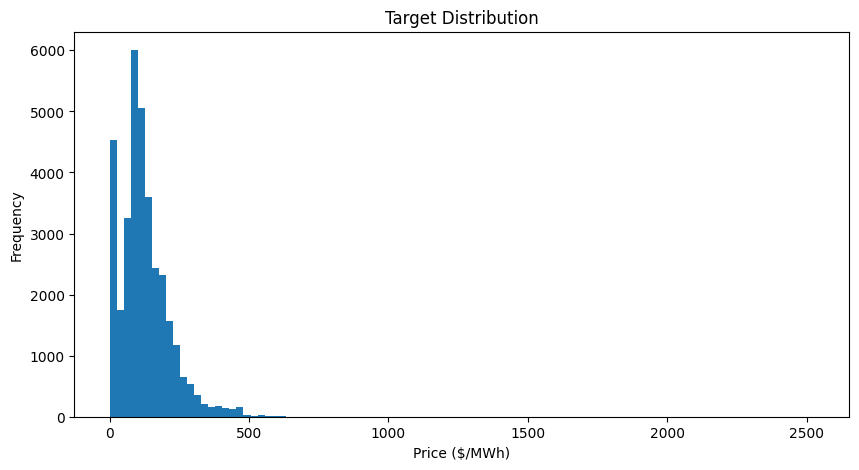


95th percentile: 290.38949999999994
99th percentile: 441.37395
99.5th percentile: 468.66734999999716
Maximum: 2527.41


In [140]:
# ============================================================
# STEP 27: Examine target distribution
# ============================================================

import matplotlib.pyplot as plt

print(y_train.describe())

plt.figure(figsize=(10,5))
plt.hist(y_train, bins=100)
plt.title("Target Distribution")
plt.xlabel("Price ($/MWh)")
plt.ylabel("Frequency")
plt.show()

print("\n95th percentile:", y_train.quantile(0.95))
print("99th percentile:", y_train.quantile(0.99))
print("99.5th percentile:", y_train.quantile(0.995))
print("Maximum:", y_train.max())

In [141]:
# ============================================================
# STEP 28: Create log-transformed target
# ============================================================

import numpy as np

y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)
y_test_log = np.log1p(y_test)

print("Log target created")

print("\nOriginal target:")
display(y_train.describe())

print("\nLog target:")
display(y_train_log.describe())

Log target created

Original target:


count    34308.000000
mean       124.454603
std         92.017007
min          0.010000
25%         70.357500
50%        108.940000
75%        167.860000
max       2527.410000
Name: target, dtype: float64


Log target:


count    34308.000000
mean         4.398782
std          1.254551
min          0.009950
25%          4.267702
50%          4.699935
75%          5.129070
max          7.835346
Name: target, dtype: float64

In [142]:
# ============================================================
# STEP 29: Train XGBoost on log(price)
# ============================================================

from xgboost import XGBRegressor

xgb_log = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_log.fit(
    X_train_v2,
    y_train_log
)

print("Log-XGBoost Training Complete")

Log-XGBoost Training Complete


In [143]:
# ============================================================
# STEP 30: Evaluate Log-XGBoost
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

pred_log = xgb_log.predict(X_val_v2)

pred_price = np.expm1(pred_log)

mae = mean_absolute_error(
    y_val,
    pred_price
)

rmse = mean_squared_error(
    y_val,
    pred_price
) ** 0.5

r2 = r2_score(
    y_val,
    pred_price
)

print("Log-XGBoost Validation Results")

print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")

Log-XGBoost Validation Results
MAE  : 45.924
RMSE : 89.583
R²   : 0.060


In [144]:
# ============================================================
# STEP 31: Horizon predictability analysis
# ============================================================

horizons = [1, 6, 12, 24]

for h in horizons:

    corr = (
        df[target_col]
        .corr(
            df[target_col].shift(-h)
        )
    )

    print(
        f"Horizon {h:2d} hours: "
        f"correlation = {corr:.3f}"
    )

Horizon  1 hours: correlation = 0.846
Horizon  6 hours: correlation = 0.655
Horizon 12 hours: correlation = 0.649
Horizon 24 hours: correlation = 0.726


In [145]:
# ============================================================
# STEP 32: Add current price feature
# ============================================================

df["current_price"] = df[target_col]

print(
    df[
        [target_col, "current_price", "target"]
    ].head()
)

   el_price_dol_MWh_HAY2201  current_price  target
0                    171.76         171.76  73.805
1                    157.87         157.87  83.615
2                    141.00         141.00  79.310
3                    129.98         129.98  95.630
4                    136.14         136.14  95.165


In [146]:
# ============================================================
# STEP 33: Create V3 feature set
# ============================================================

v3_features = v2_features + [
    "current_price"
]

print("Number of V3 Features:", len(v3_features))

Number of V3 Features: 70


In [147]:
# ============================================================
# FIX: Add current_price to split dataframes
# ============================================================

train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

train_df["current_price"] = train_df[target_col]
val_df["current_price"] = val_df[target_col]
test_df["current_price"] = test_df[target_col]

print("current_price added to train/val/test")

print(train_df[["current_price", target_col, "target"]].head())

current_price added to train/val/test
     current_price  el_price_dol_MWh_HAY2201   target
720        123.825                   123.825  127.455
721        119.635                   119.635  124.565
722        109.170                   109.170  123.045
723        118.180                   118.180  122.860
724        124.270                   124.270  133.460


In [148]:
# ============================================================
# STEP 34: Prepare V3 train/val/test
# ============================================================

X_train_v3 = train_df[v3_features]
X_val_v3 = val_df[v3_features]
X_test_v3 = test_df[v3_features]

print(X_train_v3.shape)
print(X_val_v3.shape)
print(X_test_v3.shape)

(34308, 70)
(8751, 70)
(8728, 70)


In [149]:
from xgboost import XGBRegressor

xgb_v3 = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_v3.fit(
    X_train_v3,
    y_train
)

print("Training Complete")

Training Complete


In [150]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

pred_v3 = xgb_v3.predict(X_val_v3)

mae = mean_absolute_error(y_val, pred_v3)

rmse = mean_squared_error(
    y_val,
    pred_v3
) ** 0.5

r2 = r2_score(y_val, pred_v3)

print("XGBoost V3")

print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")

XGBoost V3
MAE  : 42.345
RMSE : 79.202
R²   : 0.265


In [151]:
# ============================================================
# STEP 37: TimeSeriesSplit Validation - corrected
# ============================================================

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
import numpy as np

# Recreate clean CV dataframe after current_price was added
cv_df = df[feature_cols + ["target", "current_price"]].copy()
cv_df = cv_df.dropna()

X_cv = cv_df[v3_features]
y_cv = cv_df["target"]

tscv = TimeSeriesSplit(n_splits=5)

rmse_scores = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_cv), start=1):

    X_train_cv = X_cv.iloc[train_idx]
    X_val_cv = X_cv.iloc[val_idx]

    y_train_cv = y_cv.iloc[train_idx]
    y_val_cv = y_cv.iloc[val_idx]

    model = XGBRegressor(
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_cv, y_train_cv)

    preds = model.predict(X_val_cv)

    rmse = mean_squared_error(
        y_val_cv,
        preds
    ) ** 0.5

    rmse_scores.append(rmse)

    print(f"Fold {fold}: RMSE = {rmse:.3f}")

print("\nAverage RMSE:", round(np.mean(rmse_scores), 3))
print("Std RMSE:", round(np.std(rmse_scores), 3))

Fold 1: RMSE = 53.445
Fold 2: RMSE = 87.156
Fold 3: RMSE = 71.189
Fold 4: RMSE = 80.143
Fold 5: RMSE = 137.788

Average RMSE: 85.944
Std RMSE: 28.273


In [152]:
# ============================================================
# STEP 38: Inspect TimeSeriesSplit fold periods
# ============================================================

cv_df = df[feature_cols + ["target", "current_price", datetime_col]].copy()
cv_df = cv_df.dropna()

X_cv = cv_df[v3_features]

tscv = TimeSeriesSplit(n_splits=5)

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_cv), start=1):

    val_period = cv_df.iloc[val_idx][datetime_col]

    print(f"Fold {fold}")
    print("Validation start:", val_period.min())
    print("Validation end  :", val_period.max())
    print("Validation rows :", len(val_period))
    print("-" * 50)

Fold 1
Validation start: 2020-01-26 01:00:00
Validation end  : 2021-01-20 00:00:00
Validation rows : 8631
--------------------------------------------------
Fold 2
Validation start: 2021-01-20 01:00:00
Validation end  : 2022-01-15 00:00:00
Validation rows : 8631
--------------------------------------------------
Fold 3
Validation start: 2022-01-15 01:00:00
Validation end  : 2023-01-10 00:00:00
Validation rows : 8631
--------------------------------------------------
Fold 4
Validation start: 2023-01-10 01:00:00
Validation end  : 2024-01-05 00:00:00
Validation rows : 8631
--------------------------------------------------
Fold 5
Validation start: 2024-01-05 01:00:00
Validation end  : 2024-12-30 00:00:00
Validation rows : 8631
--------------------------------------------------


In [153]:
# ============================================================
# STEP 39: Compare yearly target statistics
# ============================================================

temp = df[[datetime_col, "target"]].copy()

temp["year"] = temp[datetime_col].dt.year

yearly_stats = (
    temp
    .groupby("year")["target"]
    .agg([
        "count",
        "mean",
        "median",
        "std",
        "max"
    ])
)

display(yearly_stats)

,count,mean,median,std,max
year,,,,,
2019,8760,113.064190,108.1275,59.436821,704.300
2020,8784,105.093083,97.0200,65.801455,606.365
2021,8760,165.437657,140.1075,115.565011,1848.810
2022,8760,114.252692,114.9350,98.803429,2527.410
2023,8760,118.648032,121.9025,92.347694,3789.200
2024,8737,195.892331,197.6650,187.593026,4035.905


<Figure size 1200x600 with 0 Axes>

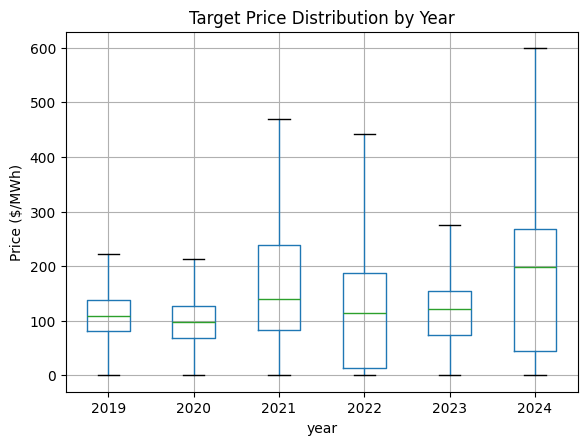

In [154]:
# ============================================================
# STEP 40: Yearly boxplot
# ============================================================

import matplotlib.pyplot as plt

temp = df[[datetime_col, "target"]].copy()
temp["year"] = temp[datetime_col].dt.year

plt.figure(figsize=(12,6))

temp.boxplot(
    column="target",
    by="year",
    showfliers=False
)

plt.title("Target Price Distribution by Year")
plt.suptitle("")
plt.ylabel("Price ($/MWh)")

plt.show()

In [155]:
# ============================================================
# STEP 41: Prediction Bias
# ============================================================

import pandas as pd

comparison = pd.DataFrame({
    "actual": y_val,
    "predicted": pred_v3
})

print("Actual Mean:")
print(comparison["actual"].mean())

print("\nPredicted Mean:")
print(comparison["predicted"].mean())

print("\nBias:")
print(
    comparison["predicted"].mean()
    -
    comparison["actual"].mean()
)

Actual Mean:
118.68264884013256

Predicted Mean:
133.4593

Bias:
14.776655969437755


In [156]:
# ============================================================
# STEP 42: Analyze forecast errors
# ============================================================

comparison = pd.DataFrame({
    "actual": y_val,
    "predicted": pred_v3
})

comparison["abs_error"] = (
    comparison["actual"]
    - comparison["predicted"]
).abs()

print(comparison["abs_error"].describe())

print("\nTop 20 largest errors")

display(
    comparison
    .sort_values(
        "abs_error",
        ascending=False
    )
    .head(20)
)

count    8751.000000
mean       42.344898
std        66.935387
min         0.004838
25%        15.277242
50%        31.207754
75%        54.818571
max      3314.021259
Name: abs_error, dtype: float64

Top 20 largest errors


,actual,predicted,abs_error
39008,3789.200,475.178741,3314.021259
38984,2643.640,359.225708,2284.414292
38178,1727.775,128.625961,1599.149039
39009,1843.635,372.399597,1471.235403
38274,1160.085,86.548073,1073.536927
38130,1174.945,159.206940,1015.738060
38192,1174.810,212.071686,962.738314
38179,970.795,130.425797,840.369203
38970,954.910,122.592560,832.317440
38442,926.310,119.159149,807.150851


In [157]:
# ============================================================
# STEP 43: Error by price regime
# ============================================================

comparison["price_bin"] = pd.cut(
    comparison["actual"],
    bins=[
        0,
        100,
        200,
        500,
        1000,
        5000
    ]
)

error_by_bin = (
    comparison
    .groupby("price_bin")["abs_error"]
    .mean()
)

print(error_by_bin)

price_bin
(0, 100]          46.109548
(100, 200]        32.481936
(200, 500]        63.236991
(500, 1000]      555.370443
(1000, 5000]    1556.545643
Name: abs_error, dtype: float64


/var/folders/02/9zbgr80n4cl11fs1ldvyrtq00000gn/T/ipykernel_2246/3309728380.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("price_bin")["abs_error"]


In [158]:
# ============================================================
# STEP 44: Spike Frequency Analysis
# ============================================================

thresholds = [200, 500, 1000]

for t in thresholds:

    count = (df["target"] > t).sum()

    pct = (
        count /
        len(df)
        * 100
    )

    print(
        f"Price > {t}: "
        f"{count:,} rows "
        f"({pct:.2f}%)"
    )

Price > 200: 10,659 rows (20.27%)
Price > 500: 516 rows (0.98%)
Price > 1000: 30 rows (0.06%)


In [159]:
!pip3 install lightgbm


[notice] A new release of pip available: 22.2.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [160]:
# ============================================================
# STEP 45: LightGBM Benchmark
# ============================================================

from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lgbm_v3 = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=8,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="regression",
    random_state=42,
    n_jobs=-1
)

lgbm_v3.fit(
    X_train_v3,
    y_train
)

pred_lgbm = lgbm_v3.predict(X_val_v3)

mae = mean_absolute_error(y_val, pred_lgbm)
rmse = mean_squared_error(y_val, pred_lgbm) ** 0.5
r2 = r2_score(y_val, pred_lgbm)

print("LightGBM V3 Validation Results")
print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003154 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 14465
[LightGBM] [Info] Number of data points in the train set: 34308, number of used features: 69
[LightGBM] [Info] Start training from score 124.454603
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

In [161]:
# ============================================
# Save XGBoost V3 Predictions
# ============================================

predicted_prices_df = pd.DataFrame({
    "datetime": X_val.index,   # if datetime is index
    "actual_price": y_val,
    "predicted_price": pred_v3
})

predicted_prices_df["error"] = (
    predicted_prices_df["actual_price"]
    - predicted_prices_df["predicted_price"]
)

predicted_prices_df["absolute_error"] = (
    predicted_prices_df["error"].abs()
)

predicted_prices_df.head()

,datetime,actual_price,predicted_price,error,absolute_error
35064,35064,4.810,20.865046,-16.055046,16.055046
35065,35065,4.460,20.252222,-15.792222,15.792222
35066,35066,5.055,17.484159,-12.429159,12.429159
35067,35067,4.970,18.334003,-13.364003,13.364003
35068,35068,6.590,18.587263,-11.997263,11.997263


In [162]:
model_df.columns

Index(['Coal', 'Diesel', 'Ele', 'Gas', 'Geo', 'Hydro', 'Solar', 'Wind', 'Wood',
       'palmerston_north_wind_kmh',
       ...
       'Diesel_lag_168', 'demand_GWh_CNI_lag_24', 'demand_GWh_CNI_lag_168',
       'demand_GWh_UNI_lag_24', 'demand_GWh_UNI_lag_168',
       'SI_WAN__active_storage_mm³_lag_24',
       'SI_WAN__active_storage_mm³_lag_168',
       'NI_TPO__active_storage_mm³_lag_24',
       'NI_TPO__active_storage_mm³_lag_168', 'target'],
      dtype='object', length=117)

In [163]:
print("datetime_utc12" in df.columns)
print("datetime_utc12" in model_df.columns)

True
False


In [164]:
predicted_prices_df = pd.DataFrame({
    "datetime": df.loc[y_val.index, "datetime_utc12"].values,
    "actual_price": y_val.values,
    "predicted_price": pred_v3
})

predicted_prices_df["error"] = (
    predicted_prices_df["actual_price"]
    - predicted_prices_df["predicted_price"]
)

predicted_prices_df["absolute_error"] = (
    predicted_prices_df["error"].abs()
)

predicted_prices_df.tail()

,datetime,actual_price,predicted_price,error,absolute_error
8746,2023-12-31 19:00:00,96.785,110.497269,-13.712269,13.712269
8747,2023-12-31 20:00:00,149.325,92.054863,57.270137,57.270137
8748,2023-12-31 21:00:00,152.760,91.212196,61.547804,61.547804
8749,2023-12-31 22:00:00,119.540,72.835098,46.704902,46.704902
8750,2023-12-31 23:00:00,52.880,71.421867,-18.541867,18.541867


In [165]:
predicted_prices_df.to_csv(
    "xgboost_v3_predictions_with_dates.csv",
    index=False
)

In [166]:
print(X_test.shape)
print(y_test.shape)

(8728, 45)
(8728,)


In [167]:
# Check features used by trained XGBoost V3
xgb_v3_features = xgb_v3.get_booster().feature_names

print(len(xgb_v3_features))
print(xgb_v3_features)

70
['hour', 'day_of_week', 'month', 'day_of_year', 'week_of_year', 'quarter', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos', 'price_lag_1', 'price_lag_2', 'price_lag_3', 'price_lag_6', 'price_lag_12', 'price_lag_24', 'price_lag_48', 'price_lag_72', 'price_lag_168', 'price_lag_336', 'price_lag_720', 'price_roll_mean_24', 'price_roll_std_24', 'price_roll_mean_168', 'price_roll_std_168', 'price_roll_mean_720', 'Coal_lag_24', 'Coal_lag_168', 'Gas_lag_24', 'Gas_lag_168', 'Diesel_lag_24', 'Diesel_lag_168', 'demand_GWh_CNI_lag_24', 'demand_GWh_CNI_lag_168', 'demand_GWh_UNI_lag_24', 'demand_GWh_UNI_lag_168', 'SI_WAN__active_storage_mm³_lag_24', 'SI_WAN__active_storage_mm³_lag_168', 'NI_TPO__active_storage_mm³_lag_24', 'NI_TPO__active_storage_mm³_lag_168', 'demand_GWh_CNI', 'demand_GWh_LNI', 'demand_GWh_LSI', 'demand_GWh_UNI', 'demand_GWh_USI', 'Coal', 'Gas', 'Hydro', 'Wind', 'Solar', 'Geo', 'SI_WAN__active_storage_mm³', 'NI_TPO__acti

In [168]:
X_test_v3 = test_df[xgb_v3_features]

In [169]:
pred_test = xgb_v3.predict(X_test_v3)

In [170]:
test_predictions_df = pd.DataFrame({
    "datetime": df.loc[y_test.index, "datetime_utc12"].values,
    "actual_price": y_test.values,
    "predicted_price": pred_test
})

test_predictions_df["error"] = (
    test_predictions_df["actual_price"]
    - test_predictions_df["predicted_price"]
)

test_predictions_df["absolute_error"] = (
    test_predictions_df["error"].abs()
)

test_predictions_df.head()

,datetime,actual_price,predicted_price,error,absolute_error
0,2024-01-01 00:00:00,21.050,87.613419,-66.563419,66.563419
1,2024-01-01 01:00:00,11.300,106.523392,-95.223392,95.223392
2,2024-01-01 02:00:00,10.280,91.952461,-81.672461,81.672461
3,2024-01-01 03:00:00,10.870,66.240089,-55.370089,55.370089
4,2024-01-01 04:00:00,9.565,76.756561,-67.191561,67.191561


In [171]:
test_predictions_df.to_csv(
    "xgboost_v3_test_predictions_with_dates.csv",
    index=False
)

In [172]:
# ============================================================
# STEP 46: Create spike classification target
# ============================================================

df["is_spike"] = (
    df["target"] > 500
).astype(int)

print(df["is_spike"].value_counts())

print(
    df["is_spike"]
    .value_counts(normalize=True)
    * 100
)

is_spike
0    52069
1      516
Name: count, dtype: int64
is_spike
0    99.018732
1     0.981268
Name: proportion, dtype: float64


In [173]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

clf = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

clf.fit(
    X_train_v3,
    (y_train > 500).astype(int)
)

spike_pred = clf.predict(X_val_v3)

print(
    classification_report(
        (y_val > 500).astype(int),
        spike_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8726
           1       0.00      0.00      0.00        25

    accuracy                           1.00      8751
   macro avg       0.50      0.50      0.50      8751
weighted avg       0.99      1.00      1.00      8751



/Users/anuthakur/.pyenv/versions/3.10.6/envs/Duckstradamus/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/anuthakur/.pyenv/versions/3.10.6/envs/Duckstradamus/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/anuthakur/.pyenv/versions/3.10.6/envs/Duckstradamus/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parame

In [174]:
neg = (y_train <= 500).sum()
pos = (y_train > 500).sum()

print("Negative:", neg)
print("Positive:", pos)

print("scale_pos_weight =", neg / pos)

Negative: 34220
Positive: 88
scale_pos_weight = 388.8636363636364


In [175]:
from xgboost import XGBClassifier

neg = (y_train <= 500).sum()
pos = (y_train > 500).sum()

clf = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=neg/pos,
    random_state=42,
    n_jobs=-1
)

clf.fit(
    X_train_v3,
    (y_train > 500).astype(int)
)

spike_pred = clf.predict(X_val_v3)

In [176]:
# ============================================================
# STEP 48A: Recent-regime experiment
# ============================================================

recent_train = split_df[
    (split_df[datetime_col] >= "2022-01-01")
    &
    (split_df[datetime_col] < "2024-01-01")
].copy()

recent_test = split_df[
    split_df[datetime_col] >= "2024-01-01"
].copy()

# Add current price
recent_train["current_price"] = recent_train[target_col]
recent_test["current_price"] = recent_test[target_col]

print("Recent Train:", recent_train.shape)
print("Recent Test :", recent_test.shape)

Recent Train: (17502, 128)
Recent Test : (8728, 128)


In [177]:
# ============================================================
# STEP 48B: Features and target
# ============================================================

X_train_recent = recent_train[v3_features]
y_train_recent = recent_train["target"]

X_test_recent = recent_test[v3_features]
y_test_recent = recent_test["target"]

print(X_train_recent.shape)
print(X_test_recent.shape)

(17502, 70)
(8728, 70)


In [178]:
# ============================================================
# STEP 48C: Train Recent-Regime XGBoost
# ============================================================

from xgboost import XGBRegressor

xgb_recent = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_recent.fit(
    X_train_recent,
    y_train_recent
)

print("Training Complete")

Training Complete


In [179]:
# ============================================================
# STEP 48D: Evaluate
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

pred_recent = xgb_recent.predict(X_test_recent)

mae = mean_absolute_error(
    y_test_recent,
    pred_recent
)

rmse = mean_squared_error(
    y_test_recent,
    pred_recent
) ** 0.5

r2 = r2_score(
    y_test_recent,
    pred_recent
)

print("Recent-Regime XGBoost")

print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")

Recent-Regime XGBoost
MAE  : 79.043
RMSE : 153.342
R²   : 0.332


In [180]:
print(recent_train.shape)
print(recent_test.shape)

print(y_train_recent.describe())
print(y_test_recent.describe())

(17502, 128)
(8728, 128)
count    17502.000000
mean       116.450899
std         95.680344
min          0.010000
25%         47.088750
50%        119.945000
75%        169.926250
max       3789.200000
Name: target, dtype: float64
count    8728.000000
mean      195.942126
std       187.656468
min         0.010000
25%        45.126250
50%       197.710000
75%       268.312500
max      4035.905000
Name: target, dtype: float64


In [181]:
print(X_train_recent.isna().sum().sum())
print(X_test_recent.isna().sum().sum())

0
0


In [182]:
# ============================================================
# STEP 49: RMSE excluding spikes
# ============================================================

from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

comparison = pd.DataFrame({
    "actual": y_val,
    "predicted": pred_v3
})

normal_hours = comparison[
    comparison["actual"] <= 500
]

rmse_normal = np.sqrt(
    mean_squared_error(
        normal_hours["actual"],
        normal_hours["predicted"]
    )
)

mae_normal = (
    normal_hours["actual"]
    - normal_hours["predicted"]
).abs().mean()

print("Normal Hours Only (<=500)")
print(f"MAE  : {mae_normal:.3f}")
print(f"RMSE : {rmse_normal:.3f}")

print("\nRows:")
print(len(normal_hours))

Normal Hours Only (<=500)
MAE  : 39.957
RMSE : 53.042

Rows:
8726


In [183]:
# ============================================================
# STEP 50: Create Spike Dataset
# ============================================================

SPIKE_THRESHOLD = 500

spikes_df = split_df[
    split_df["target"] > SPIKE_THRESHOLD
].copy()

print("Spike Events:", len(spikes_df))

print("\nPercentage:")
print(
    round(
        len(spikes_df) / len(split_df) * 100,
        2
    ),
    "%"
)

display(
    spikes_df[
        [datetime_col, "target"]
    ].head()
)

Spike Events: 516

Percentage:
1.0 %


,datetime_utc12,target
3162,2019-05-12 18:00:00,559.275
4039,2019-06-18 07:00:00,602.070
4040,2019-06-18 08:00:00,533.485
5056,2019-07-30 16:00:00,533.060
5057,2019-07-30 17:00:00,535.220


In [184]:
# ============================================================
# STEP 51: Spike vs Normal Comparison
# ============================================================

import pandas as pd

normal_df = split_df[
    split_df["target"] <= 500
].copy()

spikes_df = split_df[
    split_df["target"] > 500
].copy()

compare_cols = [
    "Coal",
    "Gas",
    "Hydro",
    "Wind",
    "Solar",
    "demand_GWh_CNI",
    "demand_GWh_LNI",
    "demand_GWh_LSI",
    "demand_GWh_UNI",
    "demand_GWh_USI",
    "SI_WAN__active_storage_mm³",
    "NI_TPO__active_storage_mm³",
    "outage_Gas_MW",
    "outage_Hyd_MW",
    "outage_Ter_MW",
    "outage_Win_MW"
]

comparison = pd.DataFrame({
    "Normal Mean": normal_df[compare_cols].mean(),
    "Spike Mean": spikes_df[compare_cols].mean()
})

comparison["Difference"] = (
    comparison["Spike Mean"] - comparison["Normal Mean"]
)

comparison["% Difference"] = (
    comparison["Difference"] / comparison["Normal Mean"] * 100
)

display(
    comparison.sort_values(
        "% Difference",
        ascending=False
    )
)

,Normal Mean,Spike Mean,Difference,% Difference
Solar,1.647387e+03,6.972403e+03,5325.015864,323.240083
Coal,1.937461e+05,4.658133e+05,272067.183375,140.424572
Gas,5.180927e+05,7.389830e+05,220890.246156,42.635274
outage_Gas_MW,5.561190e+01,7.116705e+01,15.555154,27.970908
demand_GWh_LNI,6.424049e-01,7.964244e-01,0.154020,23.975464
demand_GWh_USI,7.218633e-01,8.721686e-01,0.150305,20.821849
demand_GWh_UNI,1.348272e+00,1.619777e+00,0.271505,20.137233
demand_GWh_CNI,9.543762e-01,1.108120e+00,0.153744,16.109366
Wind,3.045444e+05,3.447125e+05,40168.030177,13.189547
Hydro,2.752576e+06,2.805250e+06,52673.371853,1.913603


In [185]:
# ============================================================
# STEP 52: Spike Timing Analysis
# ============================================================

spikes_df["hour"] = spikes_df[datetime_col].dt.hour
spikes_df["month"] = spikes_df[datetime_col].dt.month
spikes_df["year"] = spikes_df[datetime_col].dt.year
spikes_df["day_of_week"] = spikes_df[datetime_col].dt.day_name()

print("Spike Count by Hour")
display(
    spikes_df["hour"]
    .value_counts()
    .sort_index()
)

print("\nSpike Count by Month")
display(
    spikes_df["month"]
    .value_counts()
    .sort_index()
)

print("\nSpike Count by Year")
display(
    spikes_df["year"]
    .value_counts()
    .sort_index()
)

print("\nSpike Count by Day of Week")
display(
    spikes_df["day_of_week"]
    .value_counts()
)

Spike Count by Hour


hour
0     13
1     13
2     11
3     11
4     11
5     11
6     20
7     33
8     47
9     17
10    22
11    25
12    21
13    20
14    19
15    23
16    26
17    28
18    48
19    25
20    18
21    21
22    20
23    13
Name: count, dtype: int64


Spike Count by Month


month
1       7
2      17
3      33
4       7
5      43
6      15
7      67
8     312
9       6
10      6
11      2
12      1
Name: count, dtype: int64


Spike Count by Year


year
2019     12
2020      3
2021     43
2022     30
2023     25
2024    403
Name: count, dtype: int64


Spike Count by Day of Week


day_of_week
Monday       98
Tuesday      91
Sunday       79
Wednesday    73
Friday       65
Thursday     58
Saturday     52
Name: count, dtype: int64

In [186]:
df["total_storage"] = (
    df["SI_WAN__active_storage_mm³"]
    +
    df["NI_TPO__active_storage_mm³"]
)

df["storage_ratio"] = (
    df["SI_WAN__active_storage_mm³"]
    /
    df["NI_TPO__active_storage_mm³"]
)

In [187]:
df["total_demand"] = (
    df["demand_GWh_CNI"]
    +
    df["demand_GWh_LNI"]
    +
    df["demand_GWh_LSI"]
    +
    df["demand_GWh_UNI"]
    +
    df["demand_GWh_USI"]
)

In [188]:
df["scarcity_index"] = (
    df["total_demand"]
    /
    (df["total_storage"] + 1)
)

In [189]:
# ============================================================
# STEP 53: Create Scarcity Features
# ============================================================

# Total Hydro Storage
df["total_storage"] = (
    df["SI_WAN__active_storage_mm³"]
    +
    df["NI_TPO__active_storage_mm³"]
)

# Total NZ Demand
df["total_demand"] = (
    df["demand_GWh_CNI"]
    +
    df["demand_GWh_LNI"]
    +
    df["demand_GWh_LSI"]
    +
    df["demand_GWh_UNI"]
    +
    df["demand_GWh_USI"]
)

# Scarcity Index
df["scarcity_index"] = (
    df["total_demand"]
    /
    (df["total_storage"] + 1)
)

# Thermal Dependence
df["thermal_generation"] = (
    df["Coal"]
    +
    df["Gas"]
)

# Renewable Generation
df["renewable_generation"] = (
    df["Hydro"]
    +
    df["Wind"]
    +
    df["Solar"]
    +
    df["Geo"]
)

# Thermal Share
df["thermal_share"] = (
    df["thermal_generation"]
    /
    (
        df["thermal_generation"]
        +
        df["renewable_generation"]
        + 1
    )
)

print("Scarcity Features Created")

display(
    df[
        [
            "total_storage",
            "total_demand",
            "scarcity_index",
            "thermal_generation",
            "thermal_share"
        ]
    ].head()
)

Scarcity Features Created


,total_storage,total_demand,scarcity_index,thermal_generation,thermal_share
0,857.680000,3.506,0.004083,593156.4861,0.173463
1,857.878875,3.370,0.003924,597919.9269,0.182081
2,858.077750,3.257,0.003791,588154.5816,0.185358
3,858.276625,3.210,0.003736,563279.0038,0.179972
4,858.475500,3.275,0.003810,581668.5565,0.181950


In [190]:
# ============================================================
# STEP 54: Lagged Scarcity Features
# ============================================================

scarcity_cols = [
    "total_storage",
    "total_demand",
    "scarcity_index",
    "thermal_share"
]

for col in scarcity_cols:

    df[f"{col}_lag_24"] = df[col].shift(24)

    df[f"{col}_lag_168"] = df[col].shift(168)

print("Scarcity Lag Features Created")

Scarcity Lag Features Created


In [191]:
# ============================================================
# STEP 55: Rebuild Modeling Dataset
# ============================================================

new_features = [

    "total_storage",
    "total_demand",
    "scarcity_index",
    "thermal_generation",
    "thermal_share",

    "total_storage_lag_24",
    "total_storage_lag_168",

    "total_demand_lag_24",
    "total_demand_lag_168",

    "scarcity_index_lag_24",
    "scarcity_index_lag_168",

    "thermal_share_lag_24",
    "thermal_share_lag_168"
]

v4_features = v3_features + new_features

print("V3 Features:", len(v3_features))
print("V4 Features:", len(v4_features))

V3 Features: 70
V4 Features: 83


In [192]:
# ============================================================
# STEP 56: Clean Dataset
# ============================================================

model_df_v4 = df.copy()

required_cols = v4_features + ["target"]

model_df_v4 = model_df_v4.dropna(
    subset=required_cols
)

print(model_df_v4.shape)

(51787, 144)


In [193]:
# ============================================================
# STEP 57: Train / Validation Split
# ============================================================

train_v4 = model_df_v4[
    model_df_v4[datetime_col] < "2023-01-01"
]

val_v4 = model_df_v4[
    (model_df_v4[datetime_col] >= "2023-01-01")
    &
    (model_df_v4[datetime_col] < "2024-01-01")
]

X_train_v4 = train_v4[v4_features]
y_train_v4 = train_v4["target"]

X_val_v4 = val_v4[v4_features]
y_val_v4 = val_v4["target"]

print(X_train_v4.shape)
print(X_val_v4.shape)

(34308, 83)
(8751, 83)


In [ ]:
# ============================================================
# STEP 58: Train XGBoost V4
# ============================================================

from xgboost import XGBRegressor

xgb_v4 = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_v4.fit(
    X_train_v4,
    y_train_v4
)

print("XGBoost V4 Training Complete")

In [ ]:
# ============================================================
# STEP 59: Evaluate XGBoost V4
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

pred_v4 = xgb_v4.predict(X_val_v4)

mae = mean_absolute_error(
    y_val_v4,
    pred_v4
)

rmse = mean_squared_error(
    y_val_v4,
    pred_v4
) ** 0.5

r2 = r2_score(
    y_val_v4,
    pred_v4
)

print("XGBoost V4")

print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")

XGBoost V4
MAE  : 43.202
RMSE : 80.072
R²   : 0.249


In [ ]:
!pip3 install shap


[notice] A new release of pip available: 22.2.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


,feature,importance
69,current_price,0.360983
15,price_lag_1,0.055391
30,price_roll_mean_720,0.031630
28,price_roll_mean_168,0.023662
50,Coal,0.021101
26,price_roll_mean_24,0.019101
64,wellington_temp_c,0.018074
4,week_of_year,0.016678
10,dow_cos,0.016434
56,SI_WAN__active_storage_mm³,0.014444


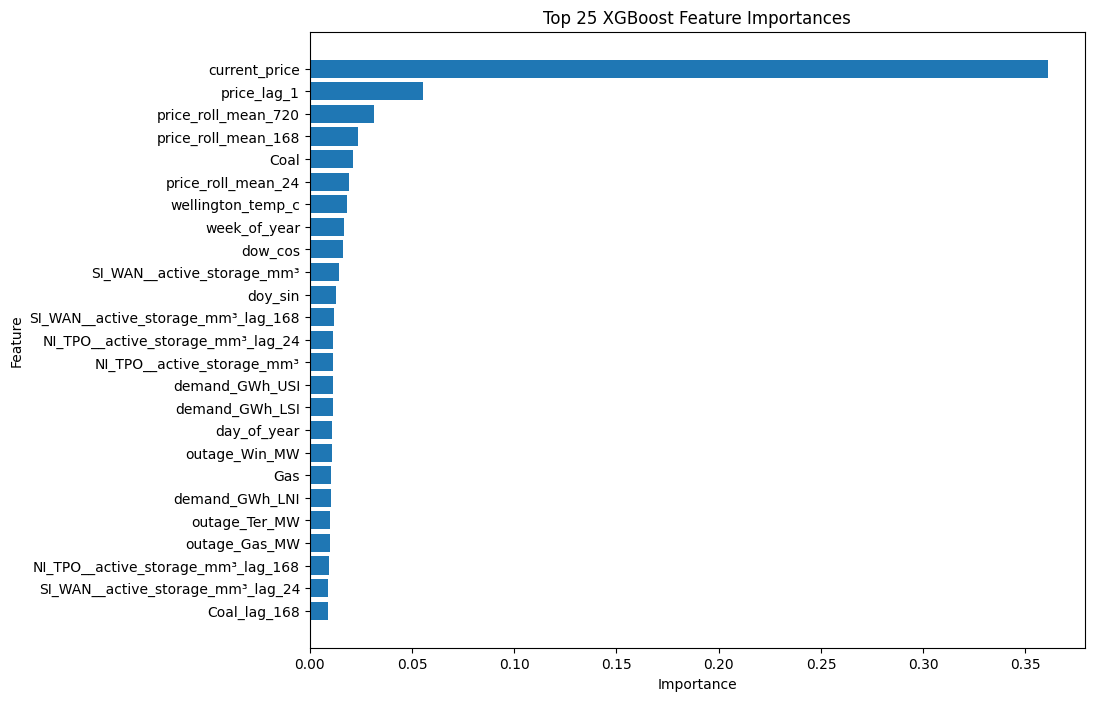

In [ ]:
# ============================================================
# STEP 60: XGBoost Built-in Feature Importance
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
    "feature": X_train_v3.columns,
    "importance": xgb_v3.feature_importances_
})

importance_df = (
    importance_df
    .sort_values("importance", ascending=False)
)

display(importance_df.head(25))

plt.figure(figsize=(10, 8))
plt.barh(
    importance_df.head(25)["feature"][::-1],
    importance_df.head(25)["importance"][::-1]
)
plt.title("Top 25 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [ ]:
# ============================================================
# STEP 61: Save Champion Model
# ============================================================

import joblib

joblib.dump(xgb_v3, "xgboost_v3_champion_model.pkl")
joblib.dump(v3_features, "v3_features.pkl")

print("Champion model and feature list saved.")

Champion model and feature list saved.


In [ ]:
# # Final Results

# XGBoost V3
# MAE  = 42.345
# RMSE = 79.202
# R²   = 0.265
# Normal-hour RMSE = 53.042

In [ ]:
print(type(y_val))
print(type(pred_v3))
print(len(y_val))
print(len(pred_v3))

<class 'pandas.core.series.Series'>
<class 'numpy.ndarray'>
8751
8751


In [ ]:
for var in [
    "val_df",
    "val_v3",
    "validation_df",
    "split_df",
    "model_df"
]:
    print(var, var in globals())

val_df True
val_v3 False
validation_df False
split_df True
model_df True


In [ ]:
plot_df = pd.DataFrame({
    "datetime": val_df[datetime_col].values,
    "actual": y_val.values,
    "predicted": pred_v3
})

plot_df["error"] = plot_df["actual"] - plot_df["predicted"]
plot_df["abs_error"] = plot_df["error"].abs()

display(plot_df.head())

,datetime,actual,predicted,error,abs_error
0,2023-01-01 00:00:00,4.810,20.865046,-16.055046,16.055046
1,2023-01-01 01:00:00,4.460,20.252222,-15.792222,15.792222
2,2023-01-01 02:00:00,5.055,17.484159,-12.429159,12.429159
3,2023-01-01 03:00:00,4.970,18.334003,-13.364003,13.364003
4,2023-01-01 04:00:00,6.590,18.587263,-11.997263,11.997263


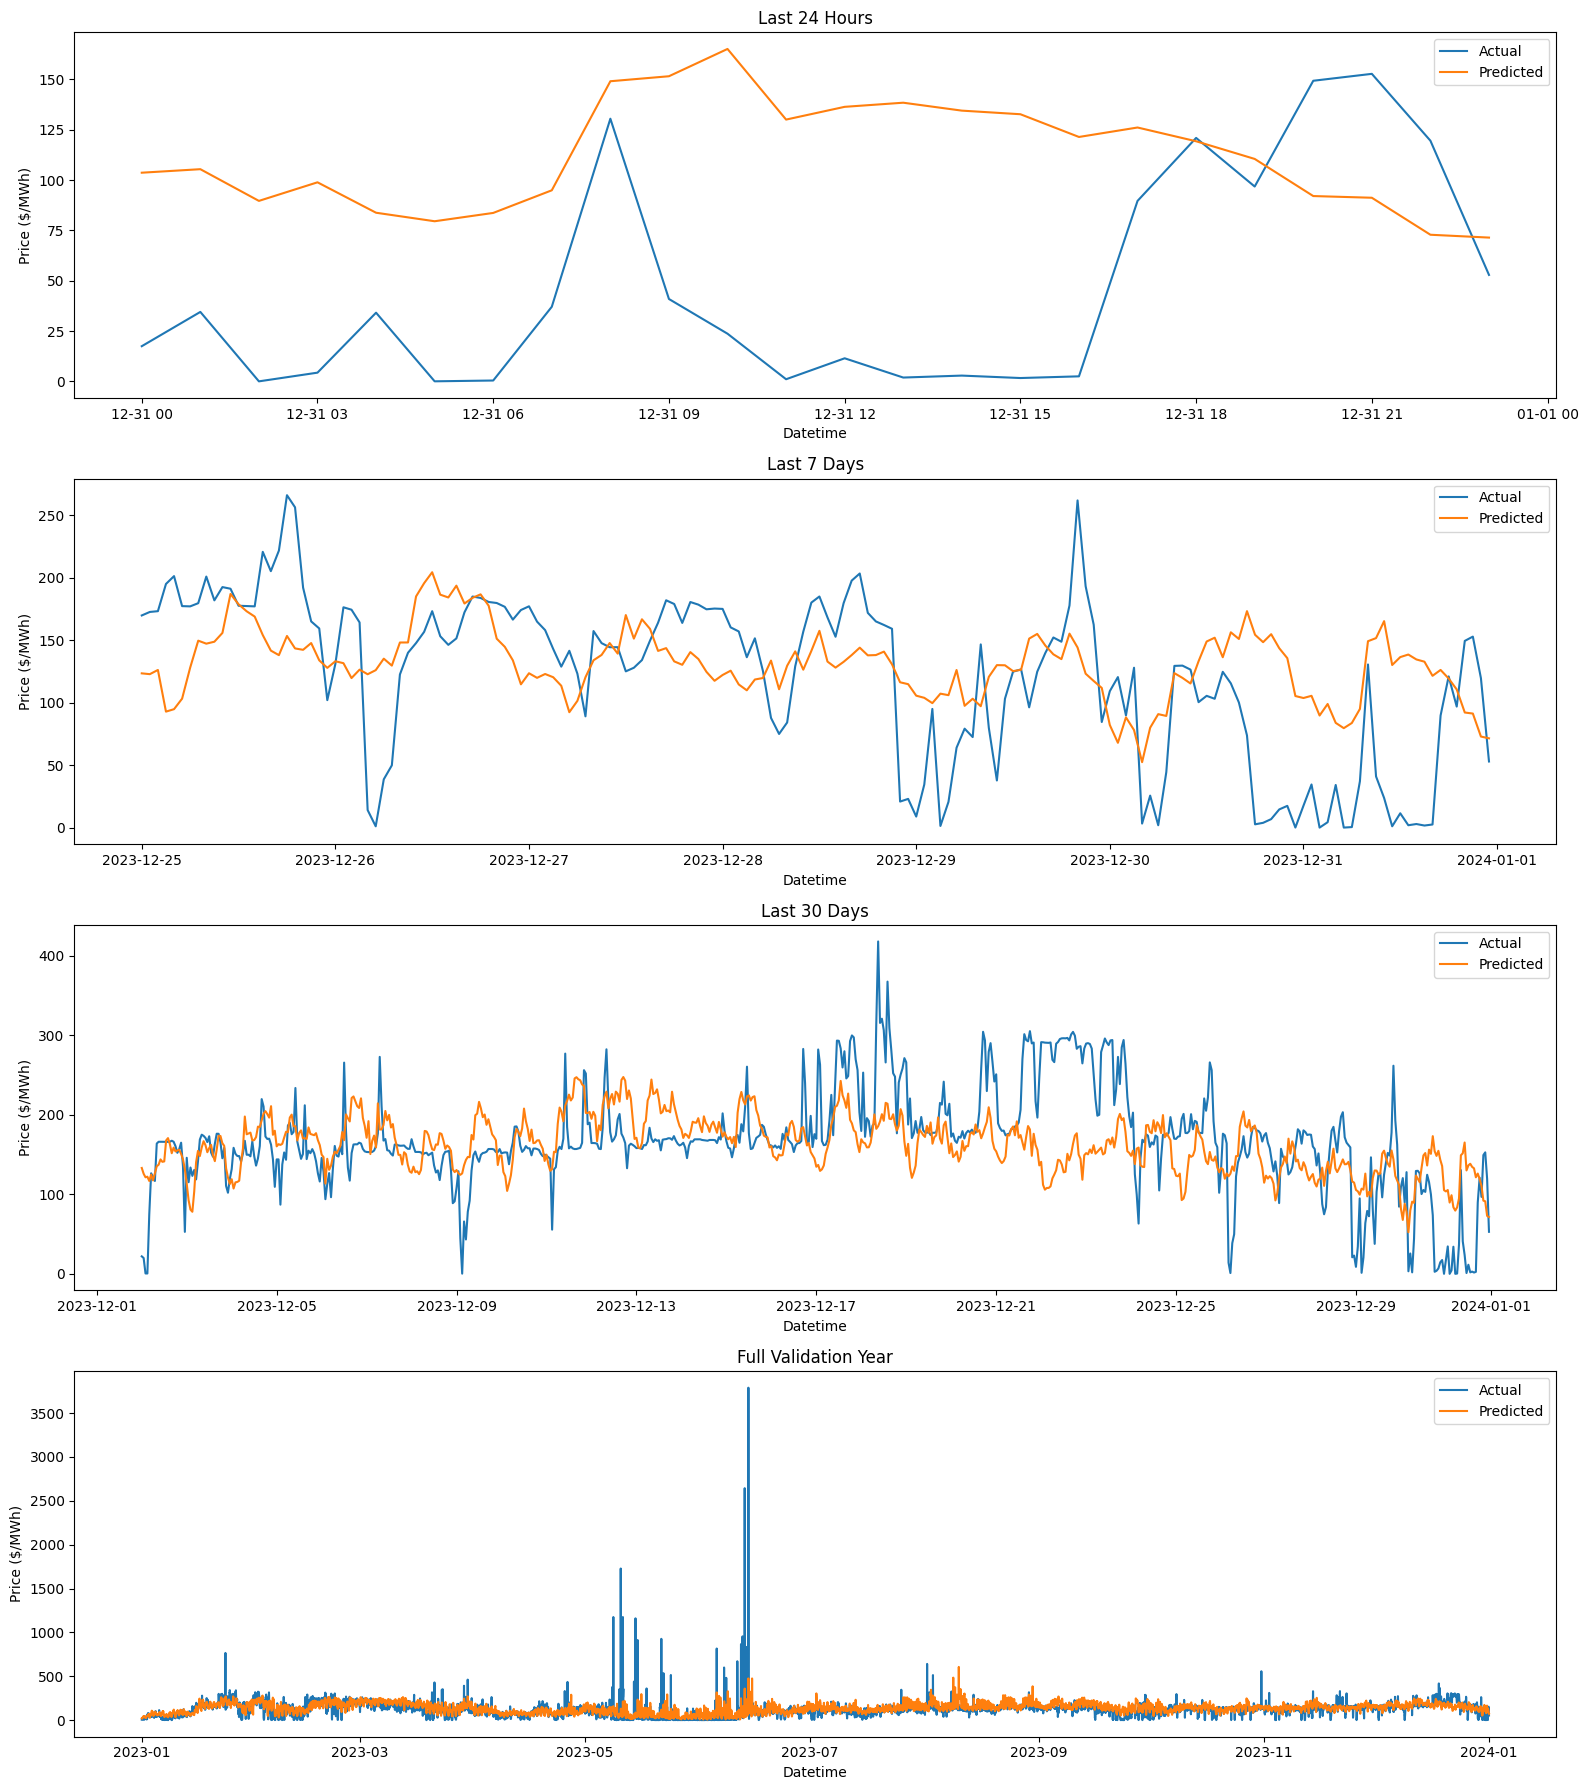

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 1, figsize=(16, 18))

views = {
    "Last 24 Hours": 24,
    "Last 7 Days": 24 * 7,
    "Last 30 Days": 24 * 30,
    "Full Validation Year": len(plot_df)
}

for ax, (title, n_rows) in zip(axes, views.items()):
    temp = plot_df.tail(n_rows)

    ax.plot(temp["datetime"], temp["actual"], label="Actual")
    ax.plot(temp["datetime"], temp["predicted"], label="Predicted")

    ax.set_title(title)
    ax.set_xlabel("Datetime")
    ax.set_ylabel("Price ($/MWh)")
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# STEP 62: Prepare data for GRU deep learning model
# ============================================================

import numpy as np
from sklearn.preprocessing import StandardScaler

# Use champion V3 features
dl_features = v3_features.copy()

# Use same train / validation / test split
X_train_dl = train_df[dl_features].copy()
X_val_dl = val_df[dl_features].copy()
X_test_dl = test_df[dl_features].copy()

y_train_dl = train_df["target"].copy()
y_val_dl = val_df["target"].copy()
y_test_dl = test_df["target"].copy()

# Scale features
scaler_X = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train_dl)
X_val_scaled = scaler_X.transform(X_val_dl)
X_test_scaled = scaler_X.transform(X_test_dl)

print("Train:", X_train_scaled.shape)
print("Validation:", X_val_scaled.shape)
print("Test:", X_test_scaled.shape)

Train: (34308, 70)
Validation: (8751, 70)
Test: (8728, 70)


In [ ]:
# ============================================================
# STEP 63: Create GRU Sequences
# ============================================================

LOOKBACK = 168      # 7 days
HORIZON = 24        # predict 24 hours ahead

def create_sequences(X, y, lookback, horizon):

    X_seq = []
    y_seq = []

    for i in range(
        lookback,
        len(X) - horizon
    ):

        X_seq.append(
            X[
                i - lookback:i
            ]
        )

        y_seq.append(
            y.iloc[
                i + horizon
            ]
        )

    return (
        np.array(X_seq),
        np.array(y_seq)
    )


X_train_seq, y_train_seq = create_sequences(
    X_train_scaled,
    y_train_dl,
    LOOKBACK,
    HORIZON
)

X_val_seq, y_val_seq = create_sequences(
    X_val_scaled,
    y_val_dl,
    LOOKBACK,
    HORIZON
)

X_test_seq, y_test_seq = create_sequences(
    X_test_scaled,
    y_test_dl,
    LOOKBACK,
    HORIZON
)

print("Train Sequences")
print(X_train_seq.shape)
print(y_train_seq.shape)

print("\nValidation Sequences")
print(X_val_seq.shape)
print(y_val_seq.shape)

print("\nTest Sequences")
print(X_test_seq.shape)
print(y_test_seq.shape)

Train Sequences
(34116, 168, 70)
(34116,)

Validation Sequences
(8559, 168, 70)
(8559,)

Test Sequences
(8536, 168, 70)
(8536,)


In [ ]:
# ============================================================
# STEP 64: Build GRU Model
# ============================================================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)

gru_model = Sequential([
    GRU(
        64,
        input_shape=(X_train_seq.shape[1], X_train_seq.shape[2]),
        return_sequences=False
    ),

    Dropout(0.2),

    Dense(32, activation="relu"),

    Dense(1)
])

gru_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

gru_model.summary()

/Users/anuthakur/.pyenv/versions/3.10.6/envs/Duckstradamus/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        26,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,225 (110.25 KB)

 Trainable params: 28,225 (110.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# STEP 65: Train GRU Model
# ============================================================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = gru_model.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
534/534 ━━━━━━━━━━━━━━━━━━━━ 37s 63ms/step - loss: 9546.4756 - mae: 64.7740 - val_loss: 7473.0591 - val_mae: 41.3677
Epoch 2/50
534/534 ━━━━━━━━━━━━━━━━━━━━ 27s 51ms/step - loss: 3853.6208 - mae: 39.0279 - val_loss: 7702.3906 - val_mae: 44.5303
Epoch 3/50
534/534 ━━━━━━━━━━━━━━━━━━━━ 27s 51ms/step - loss: 3367.6978 - mae: 36.7525 - val_loss: 7929.2563 - val_mae: 46.4364
Epoch 4/50
534/534 ━━━━━━━━━━━━━━━━━━━━ 27s 51ms/step - loss: 2956.7903 - mae: 34.6364 - val_loss: 8478.0508 - val_mae: 51.0760
Epoch 5/50
534/534 ━━━━━━━━━━━━━━━━━━━━ 27s 51ms/step - loss: 2666.7583 - mae: 32.8534 - val_loss: 8495.0332 - val_mae: 49.5004
Epoch 6/50
534/534 ━━━━━━━━━━━━━━━━━━━━ 27s 51ms/step - loss: 2491.0178 - mae: 31.8364 - val_loss: 8937.5830 - val_mae: 52.3035


In [ ]:
# ============================================================
# STEP 66: Evaluate GRU
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

gru_pred = gru_model.predict(X_val_seq).flatten()

mae = mean_absolute_error(y_val_seq, gru_pred)
rmse = mean_squared_error(y_val_seq, gru_pred) ** 0.5
r2 = r2_score(y_val_seq, gru_pred)

print("GRU Validation Results")
print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")

268/268 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
GRU Validation Results
MAE  : 41.368
RMSE : 86.447
R²   : 0.125


In [ ]:
gru_test_pred = gru_model.predict(X_test_seq).flatten()

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test_seq,
    gru_test_pred
)

rmse = mean_squared_error(
    y_test_seq,
    gru_test_pred
) ** 0.5

r2 = r2_score(
    y_test_seq,
    gru_test_pred
)

print("GRU Test Results")
print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")

267/267 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
GRU Test Results
MAE  : 104.582
RMSE : 180.057
R²   : 0.098


In [ ]:
results = pd.DataFrame({
    "Model": [
        "Persistence",
        "Weekly Baseline",
        "XGBoost V3",
        "LightGBM",
        "GRU"
    ],
    "RMSE": [
        90.18,
        116.20,
        79.20,
        81.09,
        86.45
    ]
})

results.sort_values("RMSE")

,Model,RMSE
2,XGBoost V3,79.20
3,LightGBM,81.09
4,GRU,86.45
0,Persistence,90.18
1,Weekly Baseline,116.20


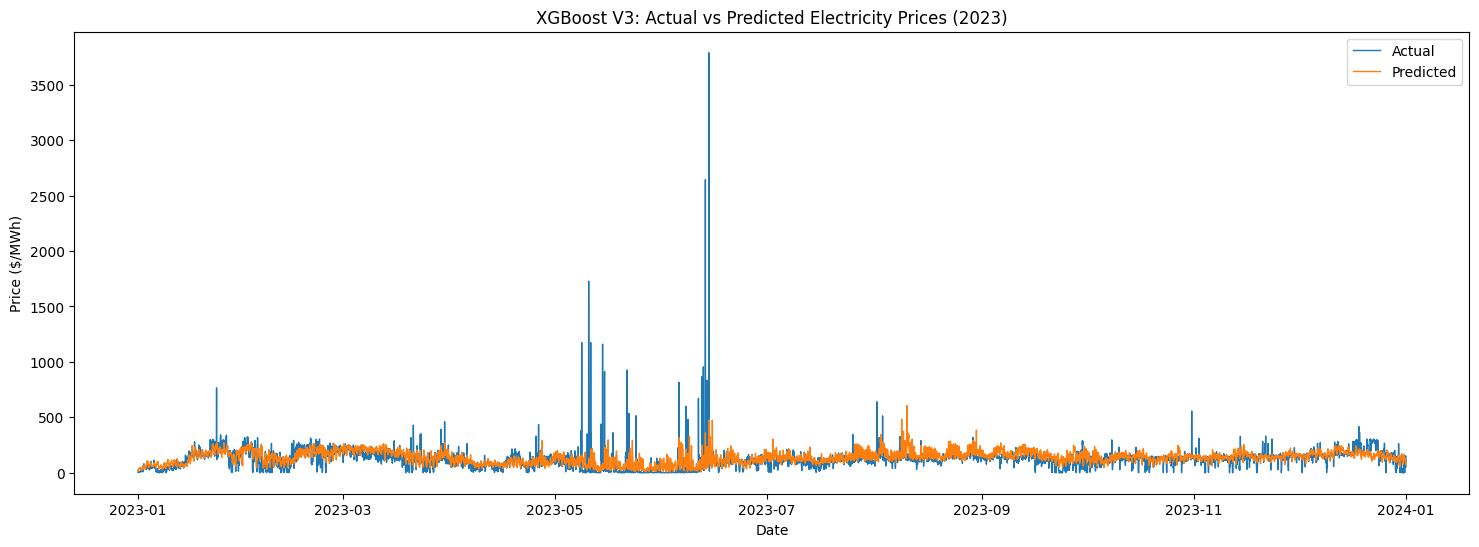

In [ ]:
# ============================================================
# FINAL VIS 1: Full Validation Year
# ============================================================

plt.figure(figsize=(18,6))

plt.plot(
    plot_df["datetime"],
    plot_df["actual"],
    label="Actual",
    linewidth=1
)

plt.plot(
    plot_df["datetime"],
    plot_df["predicted"],
    label="Predicted",
    linewidth=1
)

plt.title(
    "XGBoost V3: Actual vs Predicted Electricity Prices (2023)"
)

plt.xlabel("Date")
plt.ylabel("Price ($/MWh)")
plt.legend()

plt.show()

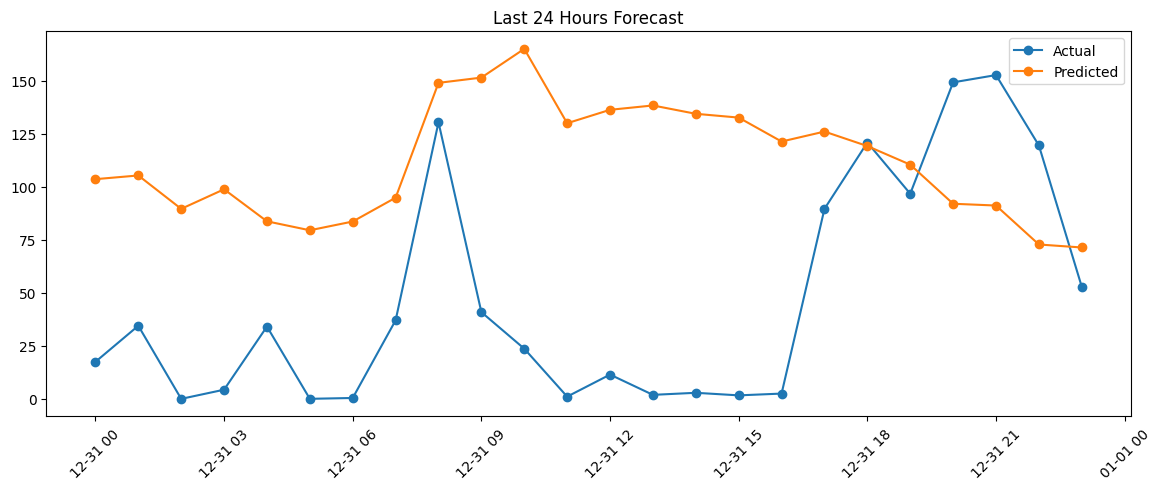

In [ ]:
# ============================================================
# FINAL VIS 2: Last 24 Hours
# ============================================================

temp = plot_df.tail(24)

plt.figure(figsize=(14,5))

plt.plot(
    temp["datetime"],
    temp["actual"],
    marker="o",
    label="Actual"
)

plt.plot(
    temp["datetime"],
    temp["predicted"],
    marker="o",
    label="Predicted"
)

plt.title("Last 24 Hours Forecast")

plt.xticks(rotation=45)

plt.legend()

plt.show()

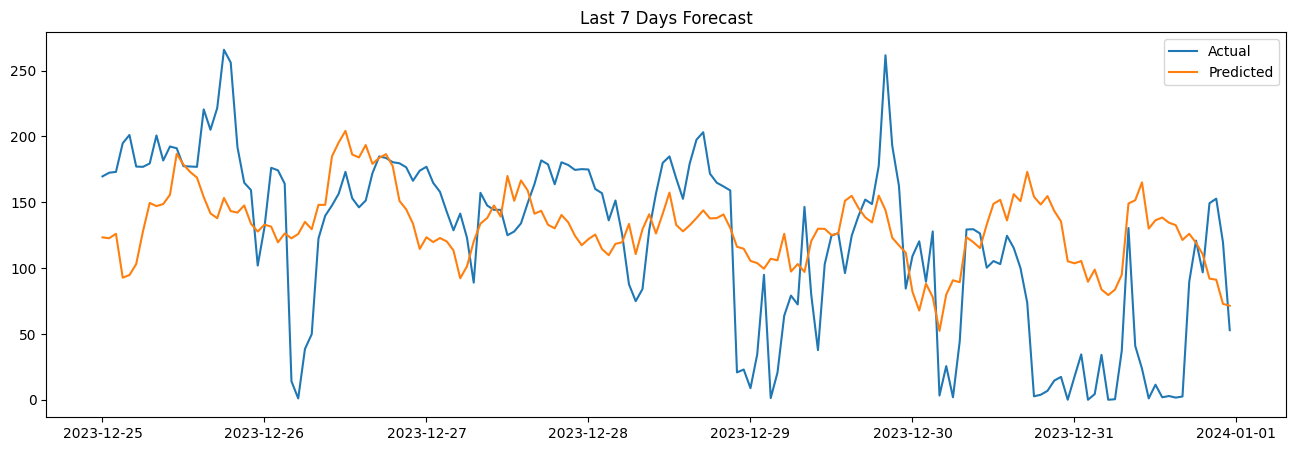

In [ ]:
# ============================================================
# FINAL VIS 3: Last 7 Days
# ============================================================

temp = plot_df.tail(24*7)

plt.figure(figsize=(16,5))

plt.plot(
    temp["datetime"],
    temp["actual"],
    label="Actual"
)

plt.plot(
    temp["datetime"],
    temp["predicted"],
    label="Predicted"
)

plt.title("Last 7 Days Forecast")

plt.legend()

plt.show()

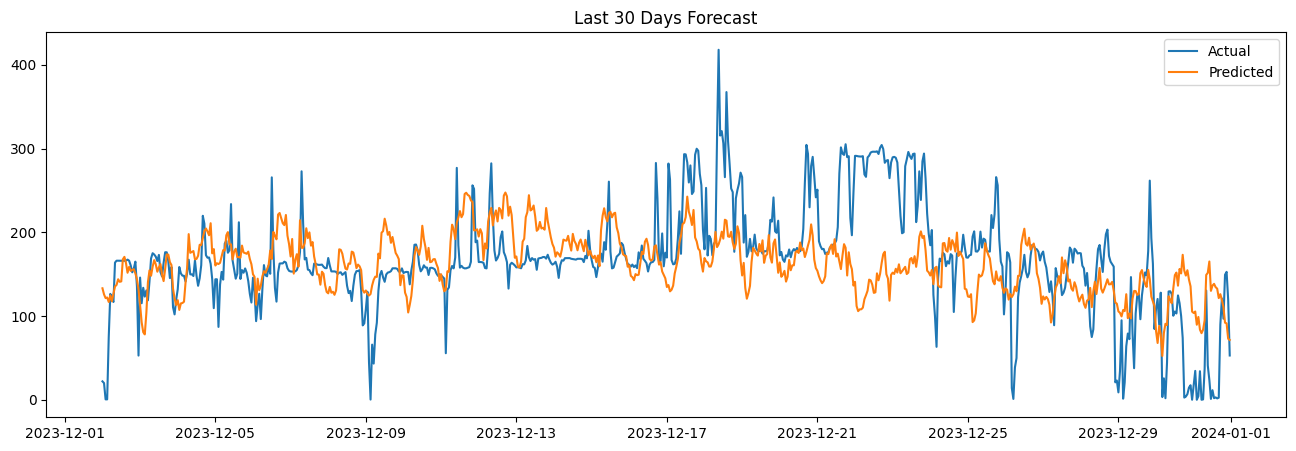

In [ ]:
# ============================================================
# FINAL VIS 4: Last 30 Days
# ============================================================

temp = plot_df.tail(24*30)

plt.figure(figsize=(16,5))

plt.plot(
    temp["datetime"],
    temp["actual"],
    label="Actual"
)

plt.plot(
    temp["datetime"],
    temp["predicted"],
    label="Predicted"
)

plt.title("Last 30 Days Forecast")

plt.legend()

plt.show()

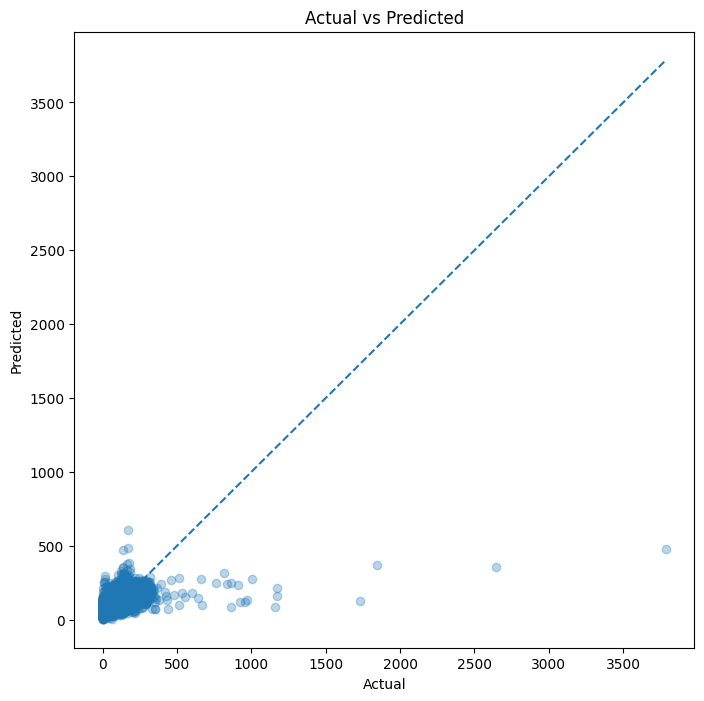

In [ ]:
# ============================================================
# FINAL VIS 5: Actual vs Predicted Scatter
# ============================================================

plt.figure(figsize=(8,8))

plt.scatter(
    plot_df["actual"],
    plot_df["predicted"],
    alpha=0.3
)

min_val = min(
    plot_df["actual"].min(),
    plot_df["predicted"].min()
)

max_val = max(
    plot_df["actual"].max(),
    plot_df["predicted"].max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.show()

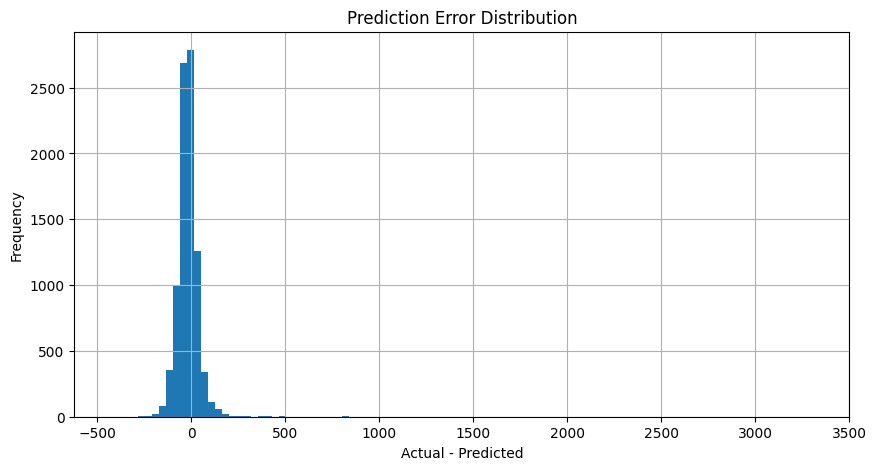

In [ ]:
# ============================================================
# FINAL VIS 6: Error Distribution
# ============================================================

plt.figure(figsize=(10,5))

plot_df["error"].hist(
    bins=100
)

plt.title(
    "Prediction Error Distribution"
)

plt.xlabel(
    "Actual - Predicted"
)

plt.ylabel(
    "Frequency"
)

plt.show()

/var/folders/02/9zbgr80n4cl11fs1ldvyrtq00000gn/T/ipykernel_2246/808529677.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


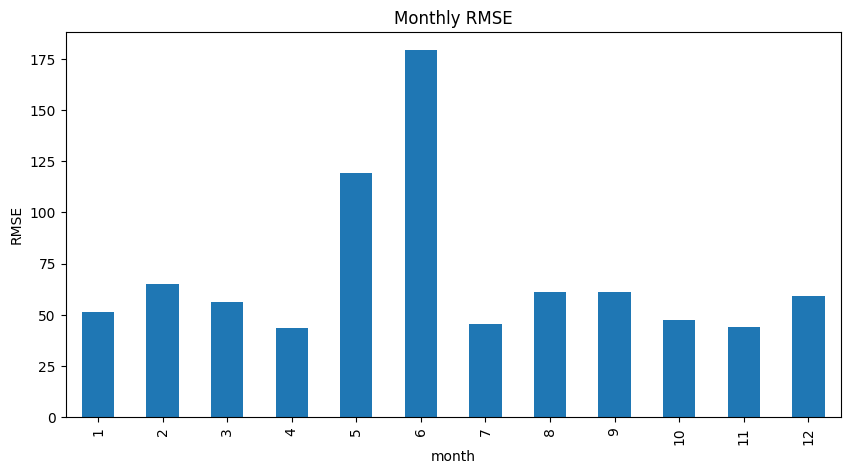

month
1      51.333519
2      65.221246
3      55.981171
4      43.355498
5     119.245760
6     179.299883
7      45.578876
8      61.195300
9      61.024080
10     47.447291
11     43.776422
12     59.311364
dtype: float64

In [ ]:
# ============================================================
# FINAL VIS 7: Monthly RMSE
# ============================================================

from sklearn.metrics import mean_squared_error
import numpy as np

plot_df["month"] = (
    plot_df["datetime"]
    .dt.month
)

monthly_rmse = (
    plot_df
    .groupby("month")
    .apply(
        lambda x:
        np.sqrt(
            mean_squared_error(
                x["actual"],
                x["predicted"]
            )
        )
    )
)

monthly_rmse.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title(
    "Monthly RMSE"
)

plt.ylabel(
    "RMSE"
)

plt.show()

display(monthly_rmse)

/var/folders/02/9zbgr80n4cl11fs1ldvyrtq00000gn/T/ipykernel_2246/3848559343.py:28: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


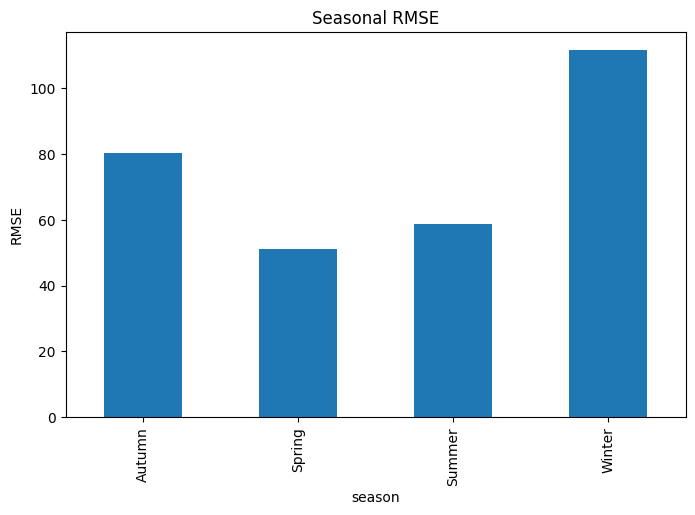

season
Autumn     80.453604
Spring     51.239802
Summer     58.675067
Winter    111.557389
dtype: float64

In [ ]:
# ============================================================
# FINAL VIS 8: Seasonal RMSE
# ============================================================

def season(month):

    if month in [12,1,2]:
        return "Summer"

    elif month in [3,4,5]:
        return "Autumn"

    elif month in [6,7,8]:
        return "Winter"

    else:
        return "Spring"


plot_df["season"] = (
    plot_df["month"]
    .apply(season)
)

seasonal_rmse = (
    plot_df
    .groupby("season")
    .apply(
        lambda x:
        np.sqrt(
            mean_squared_error(
                x["actual"],
                x["predicted"]
            )
        )
    )
)

seasonal_rmse.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title(
    "Seasonal RMSE"
)

plt.ylabel(
    "RMSE"
)

plt.show()

display(seasonal_rmse)

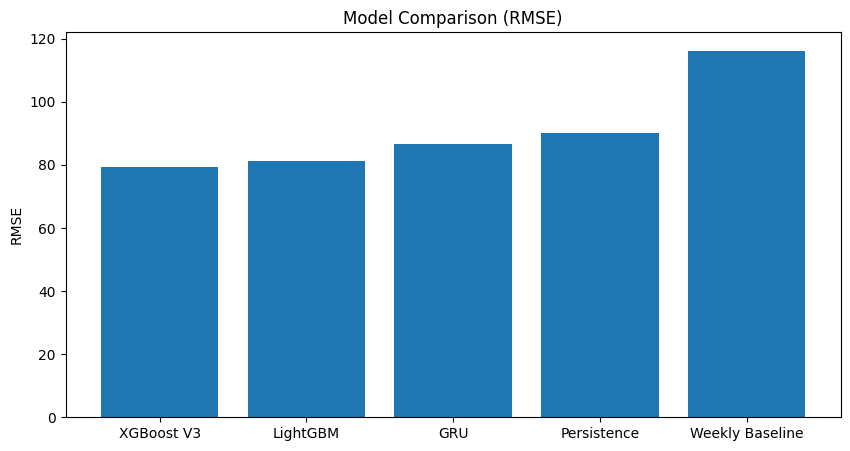

,Model,RMSE
2,XGBoost V3,79.20
3,LightGBM,81.09
4,GRU,86.45
0,Persistence,90.18
1,Weekly Baseline,116.20


In [ ]:
# ============================================================
# FINAL VIS 10: Model Comparison
# ============================================================

results = pd.DataFrame({
    "Model": [
        "Persistence",
        "Weekly Baseline",
        "XGBoost V3",
        "LightGBM",
        "GRU"
    ],
    "RMSE": [
        90.18,
        116.20,
        79.20,
        81.09,
        86.45
    ]
})

results = results.sort_values("RMSE")

plt.figure(figsize=(10,5))

plt.bar(
    results["Model"],
    results["RMSE"]
)

plt.title(
    "Model Comparison (RMSE)"
)

plt.ylabel(
    "RMSE"
)

plt.show()

display(results)

In [ ]:
importance_df.to_csv(
    "feature_importance.csv",
    index=False
)

monthly_rmse.to_csv(
    "monthly_rmse.csv"
)

seasonal_rmse.to_csv(
    "seasonal_rmse.csv"
)